In [1]:
import aopy
from aopy.data import db
from aopy.analysis import accllr
import os
import numpy as np
from scipy import signal
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import traceback
from scipy.stats import zscore
import datetime
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib import colors
from matplotlib.gridspec import GridSpec
from statannotations.Annotator import Annotator
from scipy.stats import wilcoxon

from aopy.visualization import annotate_spatial_map_channels, place_Opto32_subplots, plot_angles
from aopy.data.bmi3d import tabulate_ts_data
from aopy.preproc.bmi3d import get_laser_trial_times
from aopy.preproc.quality import detect_bad_trials
from aopy.analysis.connectivity import get_acq_ch_near_stimulation_site, calc_connectivity_map_coh, prepare_erp
from aopy.analysis import calc_itpc
from aopy.analysis.latency import detect_itpc_response
from aopy.analysis import calc_stat_over_dist_from_pos, calc_stat_over_angle_from_pos
from aopy.analysis import calc_fdrc_ranktest, calc_tfr_mean_fdrc_ranktest, calc_tfr_mean
from aopy.visualization import plot_annotated_spatial_drive_map_stim, plot_annotated_stim_drive_data
from aopy.visualization import overlay_sulci_on_spatial_map, plot_xy_scalebar, plot_tf_map_grid, plot_spatial_drive_maps
from aopy.analysis import calc_spatial_data_correlation, calc_spatial_tf_data_correlation
from aopy.analysis.connectivity import calc_connectivity_coh

data_dir = '/media/moor-data/raw'
preproc_dir = '/data/preprocessed'
postproc_dir = '/data/postprocessed/leo'
fig_dir = './figures'

version = 'v250623'


/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
sns.set_theme('paper', style='ticks', font_scale=1, font="Arial", rc={
    'svg.fonttype': 'none',
    "font.size" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [3]:
from connectivity_analysis import *
from connectivity_plotting import *

## Load data

In [4]:
# Precomputed connectivity from all sites
b_all_sites = aopy.data.pkl_read(
    f'beignet_connectivity_all_sites_{version}.pkl', postproc_dir)
a_all_sites = aopy.data.pkl_read(
    f'affi_connectivity_all_sites_{version}.pkl', postproc_dir)

## Plot all sites connectivity

  0%|          | 0/32 [00:00<?, ?it/s]

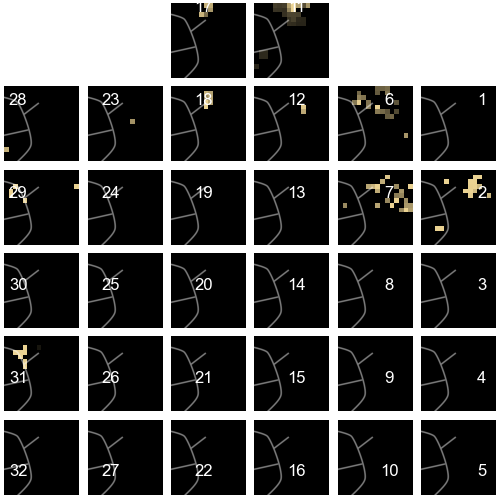

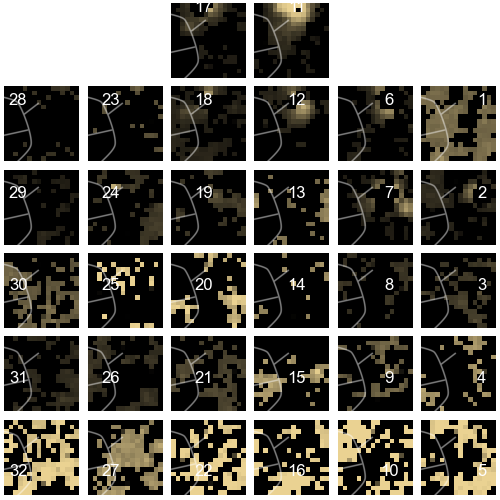

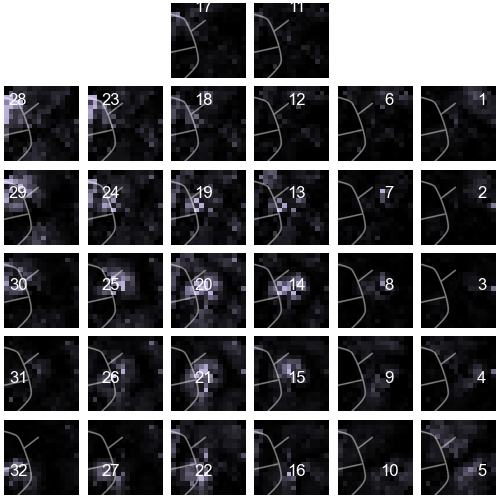

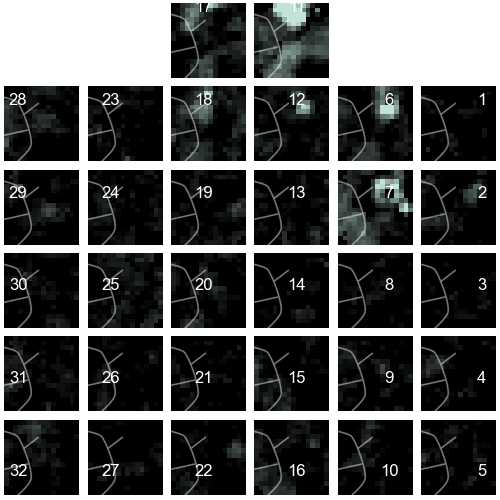

  0%|          | 0/32 [00:00<?, ?it/s]

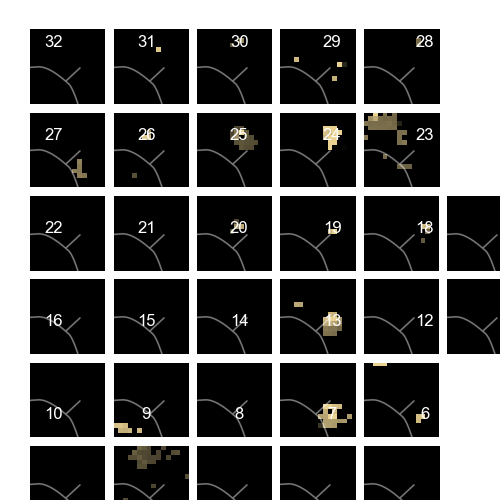

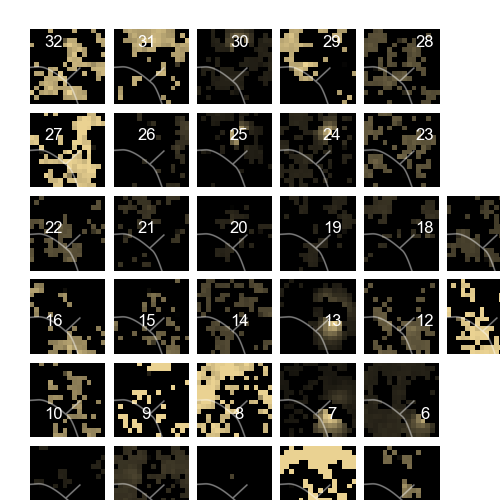

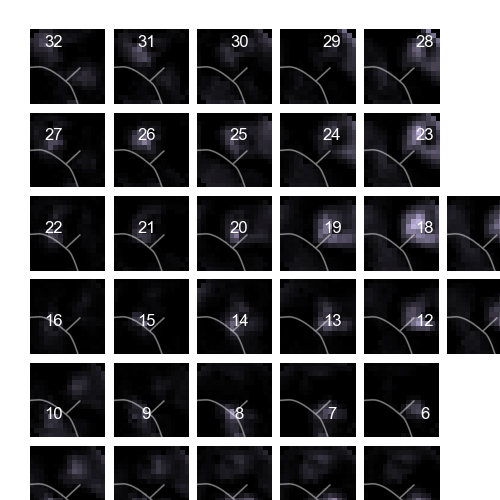

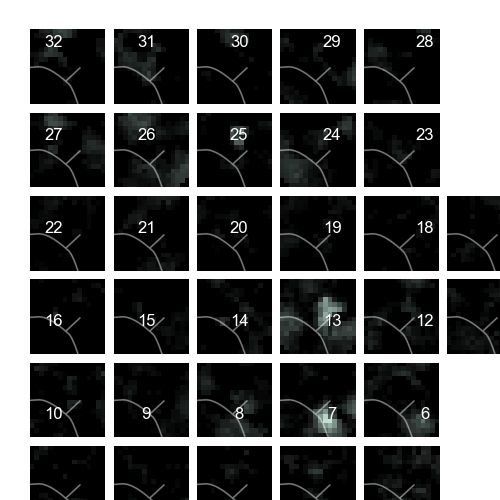

In [5]:
band = (50,150)
window = (0,1)
alpha = 0.01
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    theta = 0 if subject == 'beignet' else 90
    stim_ch = subj_data['sites']
    freqs = subj_data['freqs']
    time = subj_data['time']
    elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=theta)

    fig2, ax_accllr = place_Opto32_subplots(theta=theta)
    fig3, ax_itpc = place_Opto32_subplots(theta=theta)
    fig4, ax_gc = place_Opto32_subplots(theta=theta)
    fig5, ax_slic = place_Opto32_subplots(theta=theta)
    for idx, stim_site in enumerate(tqdm(stim_ch)):
                
        # AccLLR
        plot_annotated_spatial_drive_map_stim(subj_data['accllr_map'][idx], stim_site, subject, 'lm1', theta, 
                                              cmap=cmap_accllr, clim=(0,1), interp_method='cubic', 
                                              colorbar=False, color='w', ax=ax_accllr[idx])        
        
        # ITPC
        diff, p = calc_fdrc_ranktest(subj_data['itpc_map'][idx], subj_data['itpc_null_maps'][idx], alpha=alpha)
        conn = convert_latency_to_serr(stim_site, subj_data['itpc_latency'][idx], 
                                       subj_data['itpc_map'][idx], p)
        plot_annotated_spatial_drive_map_stim(conn, stim_site, subject, 'lm1', theta, 
                                              cmap=cmap_accllr, clim=(0,1), interp_method='cubic', 
                                              colorbar=False, color='w', ax=ax_itpc[idx])        
        
        # Granger
        diff, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['gc_map'][idx], 
                                                   subj_data['gc_null_maps'][idx], band)
        scaled = scale_data_by_p_value(diff, p)
        plot_annotated_spatial_drive_map_stim(scaled, stim_site, subject, 'lm1', theta, 
                                              cmap=cmap_granger, clim=(0,0.03), interp_method='cubic', 
                                              colorbar=False, color='w', ax=ax_gc[idx])        

        # SLIC
        diff, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['slic_map'][idx], 
                                                   subj_data['slic_null_maps'][idx], band)
        scaled = scale_data_by_p_value(diff, p)
        plot_annotated_spatial_drive_map_stim(scaled, stim_site, subject, 'lm1', theta, 
                                              cmap=cmap_slic, clim=(0, 0.1), interp_method='cubic', 
                                              colorbar=False, color='w', ax=ax_slic[idx])        
        
        
    plt.figure(fig2)
    filename = f"accllr_summary_all_{subject}.svg"
    aopy.visualization.savefig(fig_dir, filename)
    plt.figure(fig3)
    filename = f"itpc_summary_all_{subject}.svg"
    aopy.visualization.savefig(fig_dir, filename)
    plt.figure(fig4)
    filename = f"gc_summary_all_{subject}.svg"
    aopy.visualization.savefig(fig_dir, filename)
    plt.figure(fig5)
    filename = f"slic_summary_all_{subject}.svg"
    aopy.visualization.savefig(fig_dir, filename)
    plt.show()


## Latency and phase

  0%|          | 0/32 [00:00<?, ?it/s]

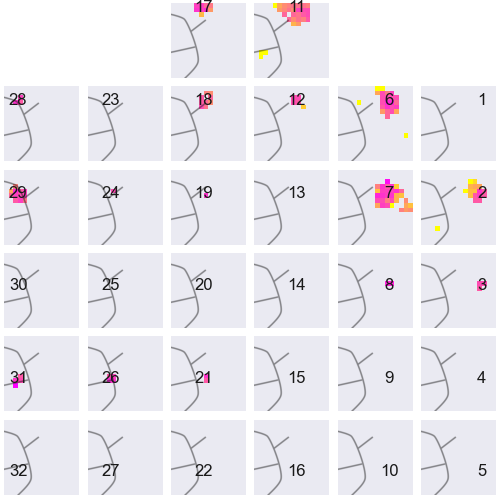

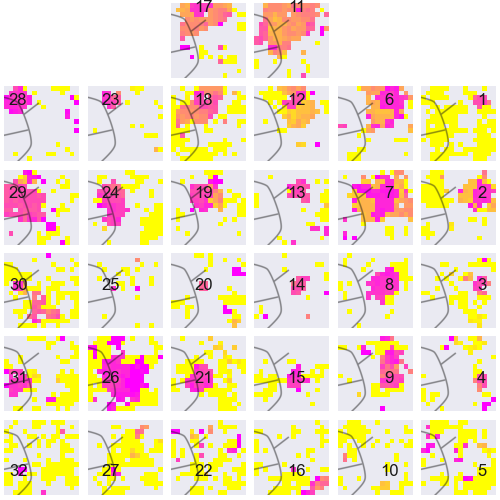

  0%|          | 0/32 [00:00<?, ?it/s]

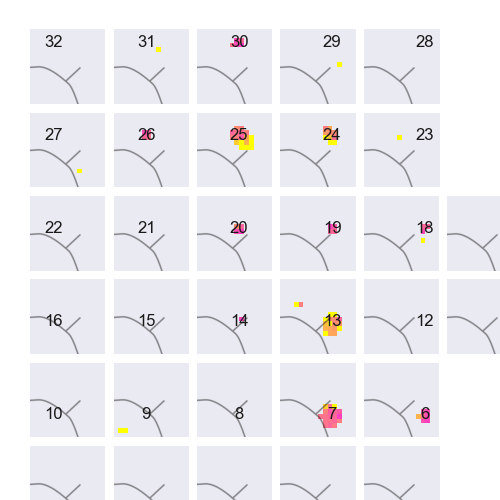

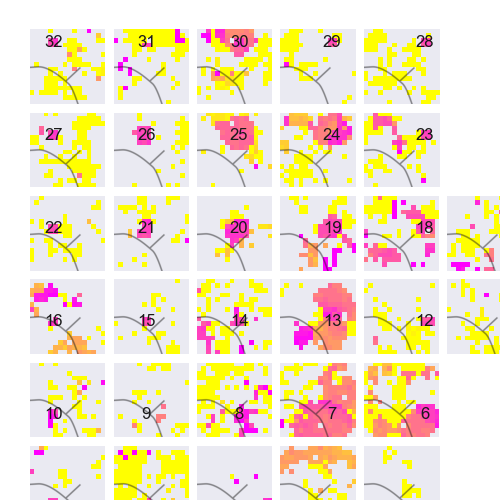

In [8]:
# Plot all latency
alpha = 0.01
band = (50,150)
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    theta = 0 if subject == 'beignet' else 90
    stim_ch = subj_data['sites']
    elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=theta)

    fig2, ax_accllr = place_Opto32_subplots(theta=theta)
    fig3, ax_itpc = place_Opto32_subplots(theta=theta)
    for idx, stim_site in enumerate(tqdm(stim_ch)):

        # AccLLR
        latency = subj_data['accllr_latency'][idx]
        latency[subj_data['accllr_p'][idx] > alpha] = np.nan
        plot_annotated_spatial_drive_map_stim(1000*latency, stim_site, subject, 'lm1', theta, 
                                              cmap='spring', clim=(10,30), interp=False,
                                              nan_color='#EAEAF2', colorbar=False, color='k', 
                                              ax=ax_accllr[idx])        
        
        # ITPC
        diff, p = calc_fdrc_ranktest(subj_data['itpc_map'][idx], 
                                     subj_data['itpc_null_maps'][idx], alpha=alpha)
        latency = subj_data['itpc_latency'][idx]
        latency[p > alpha] = np.nan
        plot_annotated_spatial_drive_map_stim(1000*latency, stim_site, subject, 'lm1', theta, 
                                              cmap='spring', clim=(10,30), interp=False, 
                                              nan_color='#EAEAF2', colorbar=False, color='k', 
                                              ax=ax_itpc[idx])        
                
    plt.show()


In [9]:
# Collect connectivity distributions
alpha = 0.01
bins = np.arange(0, 12, 0.01)
df = None
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    theta = 0 if subject == 'beignet' else 90
    stim_ch = subj_data['sites']
    elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=theta)
    stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=theta)
    
    for idx, stim_site in enumerate(tqdm(stim_ch)):

        pos = stim_pos[np.where(stim_ch == stim_site)[0][0]]
        dist = [np.linalg.norm(np.array(p) - pos) for p in elec_pos]

        # AccLLR
        latency_accllr = 1000*subj_data['accllr_latency'][idx]
        latency_accllr[subj_data['accllr_p'][idx] > alpha] = np.nan
        
        # ITPC
        diff, p = calc_fdrc_ranktest(subj_data['itpc_map'][idx], 
                                     subj_data['itpc_null_maps'][idx], alpha=alpha)
        latency_itpc = 1000*subj_data['itpc_latency'][idx]
        latency_itpc[p > alpha] = np.nan

        # SLIC
        slic, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['slic_map'][idx], 
                                              subj_data['slic_null_maps'][idx], band)
        slic[p > alpha] = np.nan

        # SLIC angle
        diff, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['slic_map'][idx], 
                                              subj_data['slic_null_maps'][idx], band)
        angle = calc_tfr_mean(freqs, time, subj_data['slic_angle_map'][idx], band)
        angle[p > alpha] = np.nan

        
        # Granger
        gp, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['gc_map'][idx], 
                                            subj_data['gc_null_maps'][idx], band)

        gp[p > alpha] = np.nan

        
        df = pd.concat([df, pd.DataFrame({
            'subject': subject,
            'stim_site': stim_site,
            'latency_accllr': latency_accllr,
            'latency_itpc': latency_itpc,
            'slic': slic,
            'angle': angle,
            'gp': gp,
            'distance': dist,
        })])
        
df.reset_index(inplace=True)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

In [10]:
# Sweep through latency cutoffs
alpha = 0.01
cutoffs = np.arange(0.005, 0.1, 0.005)
subject_accllr = []
subject_itpc = []
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    stim_ch = subj_data['sites']
    
    accllr = []
    itpc = []
    for cutoff in tqdm(cutoffs):
        accllr_conn_cutoff = []
        itpc_conn_cutoff = []
        for idx, stim_site in enumerate(stim_ch):
        
            # AccLLR
            serr = convert_latency_to_serr(stim_site, subj_data['accllr_latency'][idx], 
                                           subj_data['erp_map'][idx], subj_data['accllr_p'][idx], 
                                           alpha=alpha, latency_cutoff=cutoff)
            total = np.count_nonzero(serr)
            accllr_conn_cutoff.append(total)
            
            # ITPC
            diff, itpc_p = calc_fdrc_ranktest(subj_data['itpc_map'][idx], subj_data['itpc_null_maps'][idx])
            serr = convert_latency_to_serr(stim_site, subj_data['itpc_latency'][idx], 
                                           subj_data['itpc_map'][idx], itpc_p, 
                                           alpha=alpha, latency_cutoff=cutoff)
            total = np.count_nonzero(serr)
            itpc_conn_cutoff.append(total)
            

        accllr.append(accllr_conn_cutoff)
        itpc.append(itpc_conn_cutoff)
        
    subject_accllr.append(accllr)
    subject_itpc.append(itpc)

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

In [11]:
df_sweep = None
for idx, subject in enumerate(['beignet', 'affi']):
    nonzero = np.array(subject_accllr[idx]).astype(float)
    nonzero[:,np.all(nonzero == 0, axis=0)] = np.nan
    for site_idx in range(nonzero.shape[1]):
        df_sweep = pd.concat([df_sweep, pd.DataFrame({
            'subject': subject,
            'accllr': [n[site_idx] for n in nonzero],
            'site_idx': site_idx,
            'cutoff': 1000*cutoffs,
        })])
df_sweep.reset_index(inplace=True)


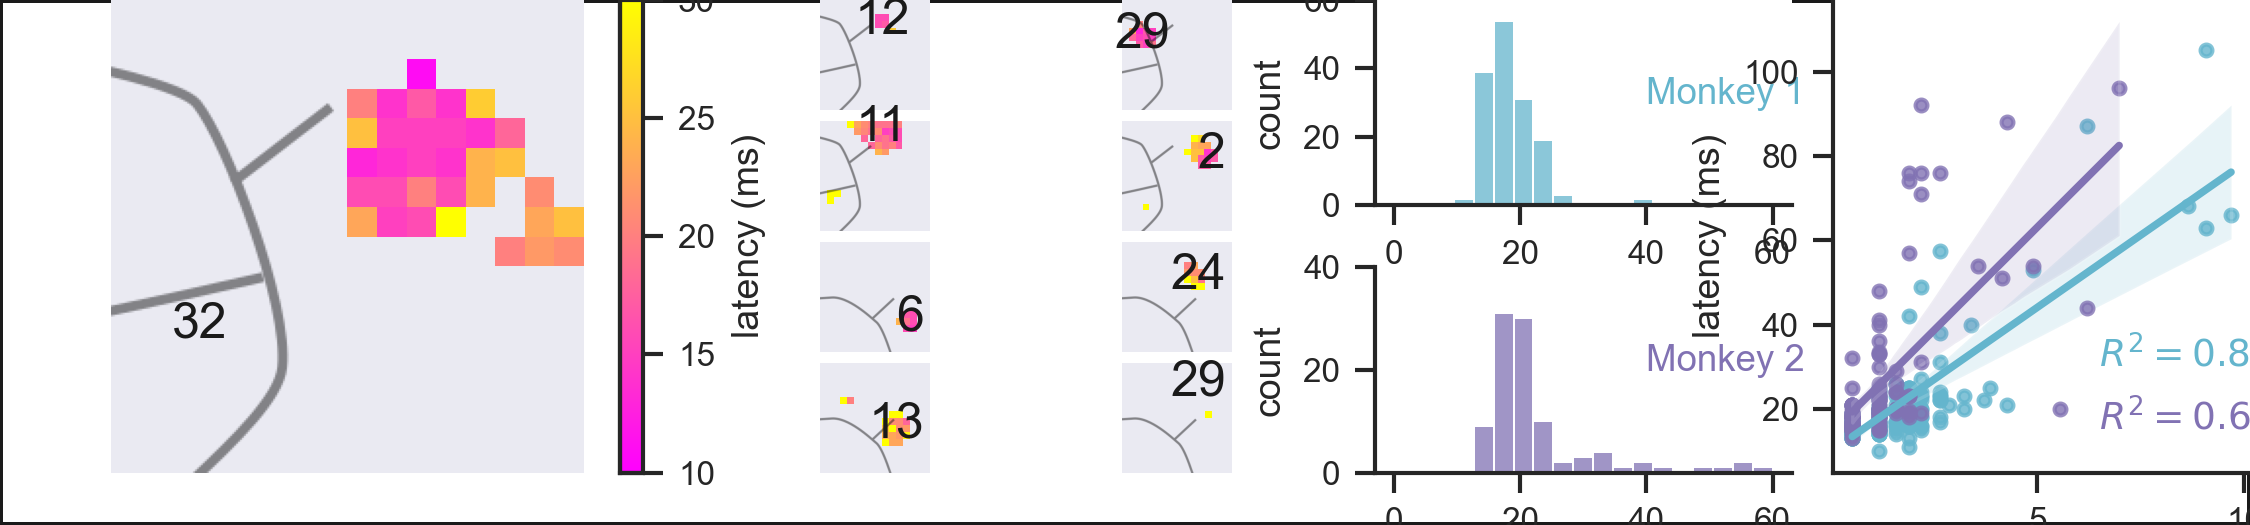

In [12]:
# Plot examples larger
fig = plt.figure(figsize=(7.5, 1.75), dpi=300, edgecolor='k', linewidth=1)
wr = [0.35, 0.1, 0.15, 0.2, 0.2]
grid2 = GridSpec(2, 5, width_ratios=wr, wspace=0.1, hspace=0.3)
grid3 = GridSpec(3, 5, width_ratios=wr, wspace=0.1, hspace=0.1)
grid4 = GridSpec(4, 5, width_ratios=wr, wspace=0.1, hspace=0.1)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)

# Big latency example
ax = fig.add_subplot(grid2[:,0])
subject = 'beignet'
theta = 0
subj_data = aopy.data.pkl_read(
    f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
latency = subj_data['accllr_latency'][6]
latency[subj_data['accllr_p'][6] > alpha] = np.nan
im, cbar = plot_annotated_spatial_drive_map_stim(1000*latency, stim_site, subject, 'lm1', theta, 
                                          cmap='spring', clim=(10,30), interp=False,
                                          nan_color='#EAEAF2', colorbar=True, color='k')                        
cbar.set_label('latency (ms)')
plt.axis('off')

# Little latency examples
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [12, 11, 6, 13])):
    
    ax = fig.add_subplot(grid4[idx,1]).axis('off')
    subj_data = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    
    latency = subj_data['accllr_latency'][stim_site_-1]
    latency[subj_data['accllr_p'][stim_site_-1] > alpha] = np.nan
    im = plot_annotated_spatial_drive_map_stim(1000*latency, stim_site_, subject_, 'lm1', theta_, 
                                              cmap='spring', clim=(10,30), interp=False,
                                              nan_color='#EAEAF2', colorbar=False, color='k')                        


# Example small response sites
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [29, 2, 24, 29])):
    
    ax = fig.add_subplot(grid4[idx,2]).axis('off')

    subj_data = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    
    latency = subj_data['accllr_latency'][stim_site_-1]
    latency[subj_data['accllr_p'][stim_site_-1] > alpha] = np.nan
    im = plot_annotated_spatial_drive_map_stim(1000*latency, stim_site_, subject_, 'lm1', theta_, 
                                              cmap='spring', clim=(10,30), interp=False,
                                              nan_color='#EAEAF2', colorbar=False, color='k')                        

                      
# Latency distribution
colors = ['c', 'm']
x = 'latency_accllr'
bins = np.linspace(0, 60, 20)
ax_1 = fig.add_subplot(grid2[0,3])
sns.histplot(data=df[df['subject'] == 'beignet'], x=x, bins=bins, color=colors[0], legend=False)
plt.ylabel('count')
plt.ylim(0,60)
ax_2 = fig.add_subplot(grid2[1,3])
sns.histplot(data=df[df['subject'] == 'affi'], x=x, bins=bins, color=colors[1], legend=False)
plt.xlabel('latency (ms)')
plt.ylabel('count')
plt.ylim(0,40)
sns.despine()


ax = fig.add_subplot(grid2[:,4])
ax.set_prop_cycle(color=colors)
df_1 = df[df["subject"] == "beignet"]
df_2 = df[df["subject"] == "affi"]
sns.regplot(data=df_1, x="distance", y=x, scatter_kws={"s": 8})
sns.regplot(data=df_2, x="distance", y=x, scatter_kws={"s": 8})
import scipy
_, _, r1, p1, _ = scipy.stats.linregress(x=df_1["distance"], y=df_1[x], nan_policy='omit')
_, _, r2, p2, _ = scipy.stats.linregress(x=df_2["distance"], y=df_2[x], nan_policy='omit')
plt.text(6.5, 30, f'$R^2 = {np.round(r1,2)}$', color=colors[0], fontsize=9)
plt.text(6.5, 15, f'$R^2 = {np.round(r2,2)}$', color=colors[1], fontsize=9)
plt.xlabel('distance (cm)')
plt.ylabel('latency (ms)')
sns.despine()

obj = plt.gca().get_lines()
plt.sca(ax_1)
plt.legend([obj[0]], ['Monkey 1'], bbox_to_anchor=(0.5,0.3), loc='lower left', 
           labelcolor='linecolor', handlelength=0,  frameon=False)
plt.sca(ax_2)
plt.legend([obj[1]], ['Monkey 2'], bbox_to_anchor=(0.5,0.3), loc='lower left', 
           labelcolor='linecolor', handlelength=0, frameon=False)


filename = f'latency_overview_examples.svg'
aopy.visualization.savefig(fig_dir, filename)


In [13]:
# phase colormap
from matplotlib.colors import LinearSegmentedColormap
colors = ["black", "tan", "white", "orchid", "black"]
nodes = [0.0, 0.4, 0.5, 0.6, 1.0] # These values map to the data range
cmap_phase = LinearSegmentedColormap.from_list("my_cmap", list(zip(nodes, colors)))
# cmap_phase = 'twilight_shifted'

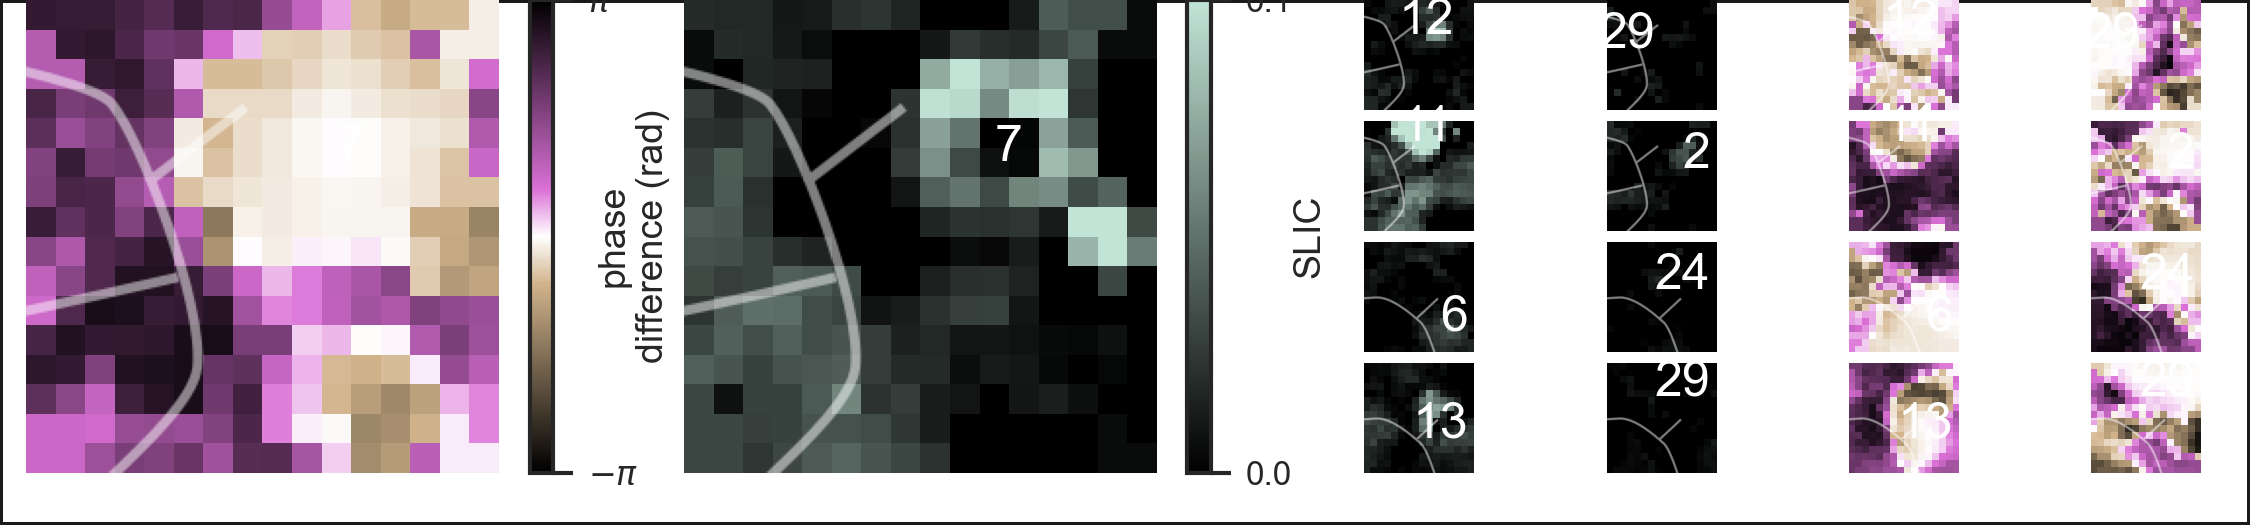

In [14]:
band = (50,150)
window = (0,1)
theta=0
subject = 'beignet'
stim_site = 7

subj_data = aopy.data.pkl_read(
    f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
idx = stim_site - 1
angle = calc_tfr_mean(freqs, time, subj_data['slic_angle_map'][idx], band)
slic, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['slic_map'][idx], 
                                      subj_data['slic_null_maps'][idx], band)

# Phase
fig = plt.figure(figsize=(7.5, 1.75), dpi=300, edgecolor='k', linewidth=1)
wr = [0.3, 0.3, 0.1, 0.1, 0.1, 0.1]
grid2 = GridSpec(2, 6, width_ratios=wr, wspace=0.1, hspace=0.3)
grid3 = GridSpec(3, 6, width_ratios=wr, wspace=0.1, hspace=0.1)
grid4 = GridSpec(4, 6, width_ratios=wr, wspace=0.1, hspace=0.1)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)


fig.add_subplot(grid2[:,0])
im, pcm = plot_annotated_spatial_drive_map_stim(angle, stim_site, subject, 'lm1', theta, 
                                      grid_size=(16,16), cmap=cmap_phase, clim=(-np.pi, np.pi), 
                                      colorbar=True, fontsize=12, color='w')
pcm.set_label('phase\ndifference (rad)', labelpad=-10)
pcm.set_ticks([-np.pi, np.pi], labels=["$-\\pi$", "$\\pi$"])

# imaginary coherence
fig.add_subplot(grid2[:,1])
scaled = scale_data_by_p_value(slic, p)
im, pcm = plot_annotated_spatial_drive_map_stim(scaled, stim_site, subject, 'lm1', theta, 
                                      grid_size=(16,16), cmap=cmap_slic, clim=(0, 0.1), 
                                      colorbar=True, fontsize=12, color='w')
pcm.set_ticks([0, 0.1])
pcm.set_label('SLIC', labelpad=0)

# Little examples
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [12, 11, 6, 13])):
    
    ax = fig.add_subplot(grid4[idx,2]).axis('off')
    subj_data = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    
    slic_diff, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['slic_map'][stim_site_-1], 
                                               subj_data['slic_null_maps'][stim_site_-1], band)
    scaled = scale_data_by_p_value(slic_diff, p)
    im = plot_annotated_spatial_drive_map_stim(scaled, stim_site_, subject_, 'lm1', theta_, 
                                               cmap=cmap_slic, clim=(0,0.1), interp=True,
                                               colorbar=False, color='w') 
    
    ax = fig.add_subplot(grid4[idx,4])
    angle = calc_tfr_mean(freqs, time, subj_data['slic_angle_map'][stim_site_-1], band)
    im = plot_annotated_spatial_drive_map_stim(angle, stim_site_, subject_, 'lm1', theta_, 
                                               grid_size=(16,16), cmap=cmap_phase, clim=(-np.pi, np.pi), 
                                               colorbar=False, fontsize=12, color='w')



# Example small response sites
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [29, 2, 24, 29])):
    
    ax = fig.add_subplot(grid4[idx,3]).axis('off')

    subj_data = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    
    slic_diff, p = calc_tfr_mean_fdrc_ranktest(freqs, time, subj_data['slic_map'][idx], 
                                               subj_data['slic_null_maps'][idx], band)
    scaled = scale_data_by_p_value(slic_diff, p)
    im = plot_annotated_spatial_drive_map_stim(scaled, stim_site_, subject_, 'lm1', theta_, 
                                              cmap=cmap_slic, clim=(0,0.1), interp=True,
                                              colorbar=False, color='w')   
    
    ax = fig.add_subplot(grid4[idx,5])
    angle = calc_tfr_mean(freqs, time, subj_data['slic_angle_map'][stim_site_-1], band)
    im = plot_annotated_spatial_drive_map_stim(angle, stim_site_, subject_, 'lm1', theta_, 
                                               grid_size=(16,16), cmap=cmap_phase, clim=(-np.pi, np.pi), 
                                               colorbar=False, fontsize=12, color='w')

filename = f'slic_angle_example.svg'
aopy.visualization.savefig(fig_dir, filename)

3.070515002651369e-05


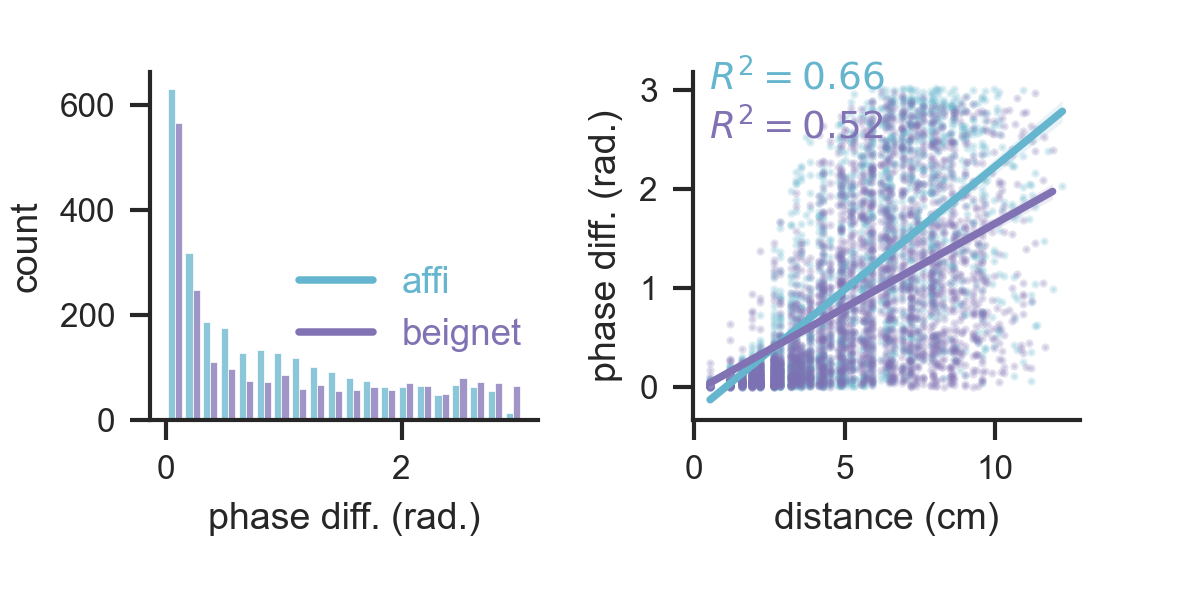

In [15]:
# SLIC angle
colors = ['c', 'm']
df['absolute_angle'] = df['angle'].abs()
x = 'absolute_angle'
print(np.min(df[x]))
plt.figure(figsize=(4,2), dpi=300)
plt.subplots_adjust(bottom=0.3, wspace=0.4)
plt.subplot(1,2,1)
sns.histplot(data=df, x=x, hue='subject', multiple="dodge", 
             bins=20, shrink=.8, palette=colors, legend=False)
plt.ylabel('count')
plt.xlabel('phase diff. (rad.)')
sns.despine()


plt.subplot(1,2,2)
plt.gca().set_prop_cycle(color=colors)
df_1 = df[df["subject"] == "affi"]
df_2 = df[df["subject"] == "beignet"]
# sns.scatterplot(data=df_1, x="distance", y=x, s=4, alpha=0.2)
# sns.scatterplot(data=df_2, x="distance", y=x, s=4, alpha=0.2)
sns.regplot(data=df_1, x="distance", y=x, scatter_kws={"s": 1, "alpha": 0.2})
sns.regplot(data=df_2, x="distance", y=x, scatter_kws={"s": 1, "alpha": 0.2})
import scipy
_, _, r1, p1, _ = scipy.stats.linregress(x=df_1["distance"], y=df_1[x], nan_policy='omit')
_, _, r2, p2, _ = scipy.stats.linregress(x=df_2["distance"], y=df_2[x], nan_policy='omit')
plt.text(0.5, 3, f'$R^2 = {np.round(r1,2)}$', color=colors[0], fontsize=9)
plt.text(0.5, 2.5, f'$R^2 = {np.round(r2,2)}$', color=colors[1], fontsize=9)

plt.xlabel('distance (cm)')
plt.ylabel('phase diff. (rad.)')

obj = plt.gca().get_lines()
plt.subplot(1,2,1)
plt.legend(obj, ['affi', 'beignet'], bbox_to_anchor=(0.3,0.1), loc='lower left', 
           labelcolor='linecolor', frameon=False)
sns.despine()

filename = f'angle_distribution.svg'
aopy.visualization.savefig(fig_dir, filename)


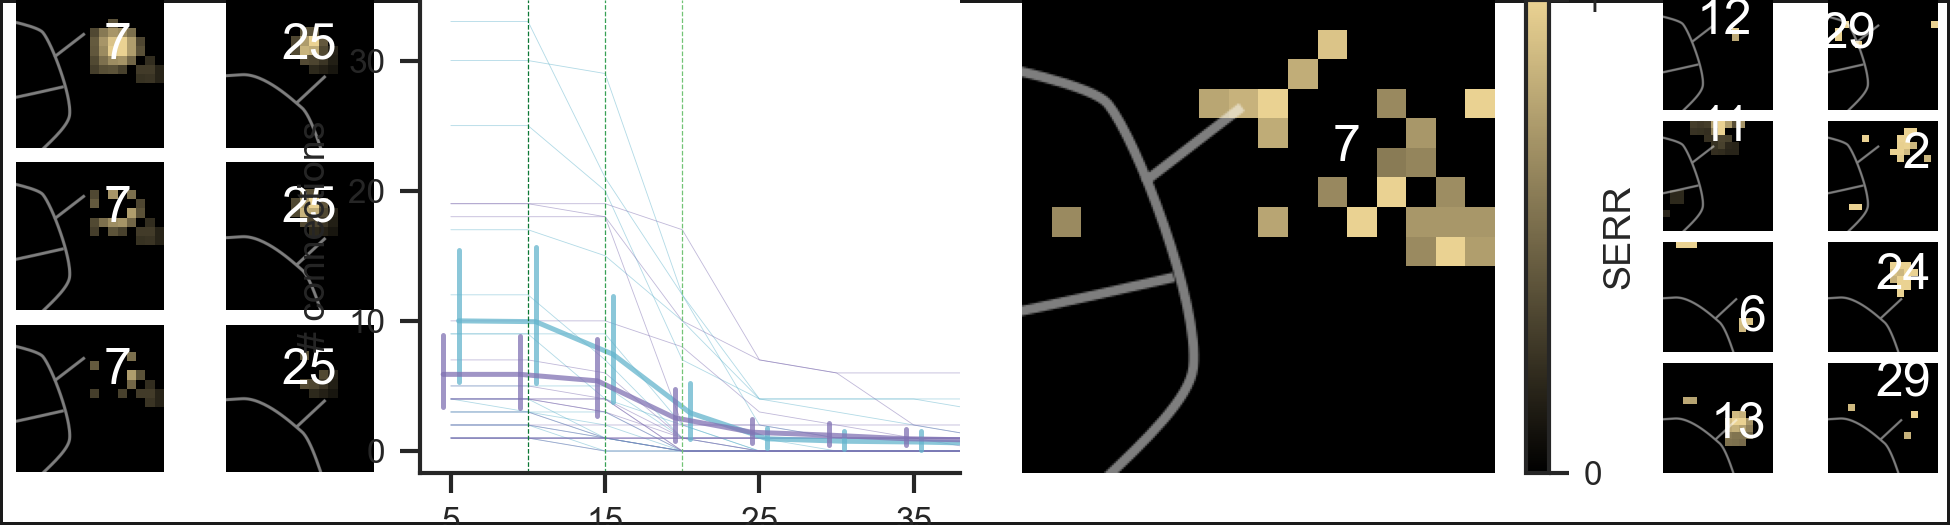

In [16]:
fig = plt.figure(figsize=(6.5, 1.75), dpi=300, edgecolor='k', linewidth=1)
wr = [0.1, 0.1, 0.3, 0.35, 0.075, 0.075]
grid2 = GridSpec(2, 6, width_ratios=wr, wspace=0.1, hspace=0.3)
grid3 = GridSpec(3, 6, width_ratios=wr, wspace=0.1, hspace=0.1)
grid4 = GridSpec(4, 6, width_ratios=wr, wspace=0.1, hspace=0.1)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)

# Cutoff sweep
cutoff_colors = sns.color_palette('Greens', n_colors=5)[4:1:-1]
for stim_idx, (subject, theta, stim_site) in enumerate(zip(
    ['beignet', 'affi'], [0, 90], [7, 25])):
    
    for idx, cutoff in enumerate([0.010, 0.015, 0.02]):
        fig.add_subplot(grid3[idx, stim_idx]).axis('off')

        subj_data = aopy.data.pkl_read(
            f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)

        serr = convert_latency_to_serr(stim_site, subj_data['accllr_latency'][stim_site-1], 
                                       subj_data['erp_map'][stim_site-1], subj_data['accllr_p'][stim_site-1], 
                                       alpha=alpha, latency_cutoff=cutoff)
        im = plot_annotated_spatial_drive_map_stim(serr, stim_site, subject, 'lm1', theta, 
                                                   cmap=cmap_accllr, clim=(0,1), interp=True, 
                                                   colorbar=False, color='w')  
for idx, cutoff in enumerate([0.010, 0.015, 0.02]):
    ax = fig.add_subplot(grid3[idx, 0])
    ax.axis('off')
    ax.text(-0.9,0.4,f'{int(cutoff*1000)} ms', color=cutoff_colors[idx])
        
ax = fig.add_subplot(grid2[:,2])
colors = ['c', 'm']
df_sweep['time_offset'] = df_sweep['cutoff']
df_sweep.loc[df_sweep['subject'] == 'affi', 'time_offset'] -= 0.5
df_sweep.loc[df_sweep['subject'] == 'beignet', 'time_offset'] += 0.5

plt.gca().set_prop_cycle(color=colors)
sns.lineplot(data=df_sweep, x="cutoff", y="accllr", hue="subject", units="site_idx", estimator=None, 
             linewidth=0.2, alpha=0.5, legend=False, palette=colors)
sns.lineplot(data=df_sweep, x="time_offset", y="accllr", hue="subject", err_style="bars", alpha=0.75,
            legend=False, palette=colors)
plt.xlabel('cutoff latency (ms)')
plt.ylabel('# connections')
plt.xlim(3,38)
plt.xticks([5, 15, 25, 35])
plt.vlines([10,15,20], 0, 1, transform=plt.gca().get_xaxis_transform(), 
           linewidth=0.3, colors=cutoff_colors, linestyle='--')
sns.despine()

# Big example
fig.add_subplot(grid2[:,3])
subject = 'beignet'
theta = 0
stim_site = 7
subj_data = aopy.data.pkl_read(
    f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
conn = subj_data['accllr_map'][stim_site - 1]
im, pcm = plot_annotated_spatial_drive_map_stim(conn, stim_site, subject, 'lm1', theta, 
                                      grid_size=(16,16), cmap=cmap_accllr, clim=(0, 1), 
                                      colorbar=True, fontsize=12, color='w')
pcm.set_ticks([0, 1])
pcm.set_label('SERR', labelpad=0)


# Little examples
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [12, 11, 6, 13])):
    
    ax = fig.add_subplot(grid4[idx,4]).axis('off')
    subj_data = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    
    conn = subj_data['accllr_map'][stim_site_ - 1]
    im = plot_annotated_spatial_drive_map_stim(conn, stim_site_, subject_, 'lm1', theta_, 
                                              cmap=cmap_accllr, clim=(0,1), interp=True,
                                              nan_color='#EAEAF2', colorbar=False, color='w')                        


# Example small response sites
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [29, 2, 24, 29])):
    
    ax = fig.add_subplot(grid4[idx,5]).axis('off')

    subj_data = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    
    conn = subj_data['accllr_map'][stim_site_ - 1]
    im = plot_annotated_spatial_drive_map_stim(conn, stim_site_, subject_, 'lm1', theta_, 
                                              cmap=cmap_accllr, clim=(0,1), interp=True,
                                              nan_color='#EAEAF2', colorbar=False, color='w')   


filename = f'latency_cutoff_sweep.svg'
aopy.visualization.savefig(fig_dir, filename)


## Count number of significant connections

In [17]:
band = (12, 150)

In [18]:
# Precomputed connectivity from all sites
b_all_sites = aopy.data.pkl_read(
    f'beignet_connectivity_all_sites_{version}.pkl', postproc_dir)
a_all_sites = aopy.data.pkl_read(
    f'affi_connectivity_all_sites_{version}.pkl', postproc_dir)

beignet:
-----------------



/home/aolab/leo/analyze/aopy/analysis/base.py:2053: UserWarning: Removing 4 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


0.5477452817315797
SLIC found mean: 83.44 SD: 42.56 per site
AccLLR found mean: 2.38 SD: 5.42 per site


/home/aolab/leo/analyze/aopy/analysis/base.py:2053: UserWarning: Removing 4 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


0.19428278248733385
ITPC found mean: 63.75 SD: 31.60 per site


...

0.23489869050206233
SLIC found mean: 68.75 SD: 40.69 per site
AccLLR found mean: 2.56 SD: 5.12 per site


/home/aolab/leo/analyze/aopy/analysis/base.py:2053: UserWarning: Removing 4 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


0.09363910487279722
ITPC found mean: 62.81 SD: 33.62 per site


/home/aolab/leo/analyze/aopy/analysis/base.py:2053: UserWarning: Removing 4 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


-0.2533219096770518
Granger found mean: 143.78 SD: 29.89 per site





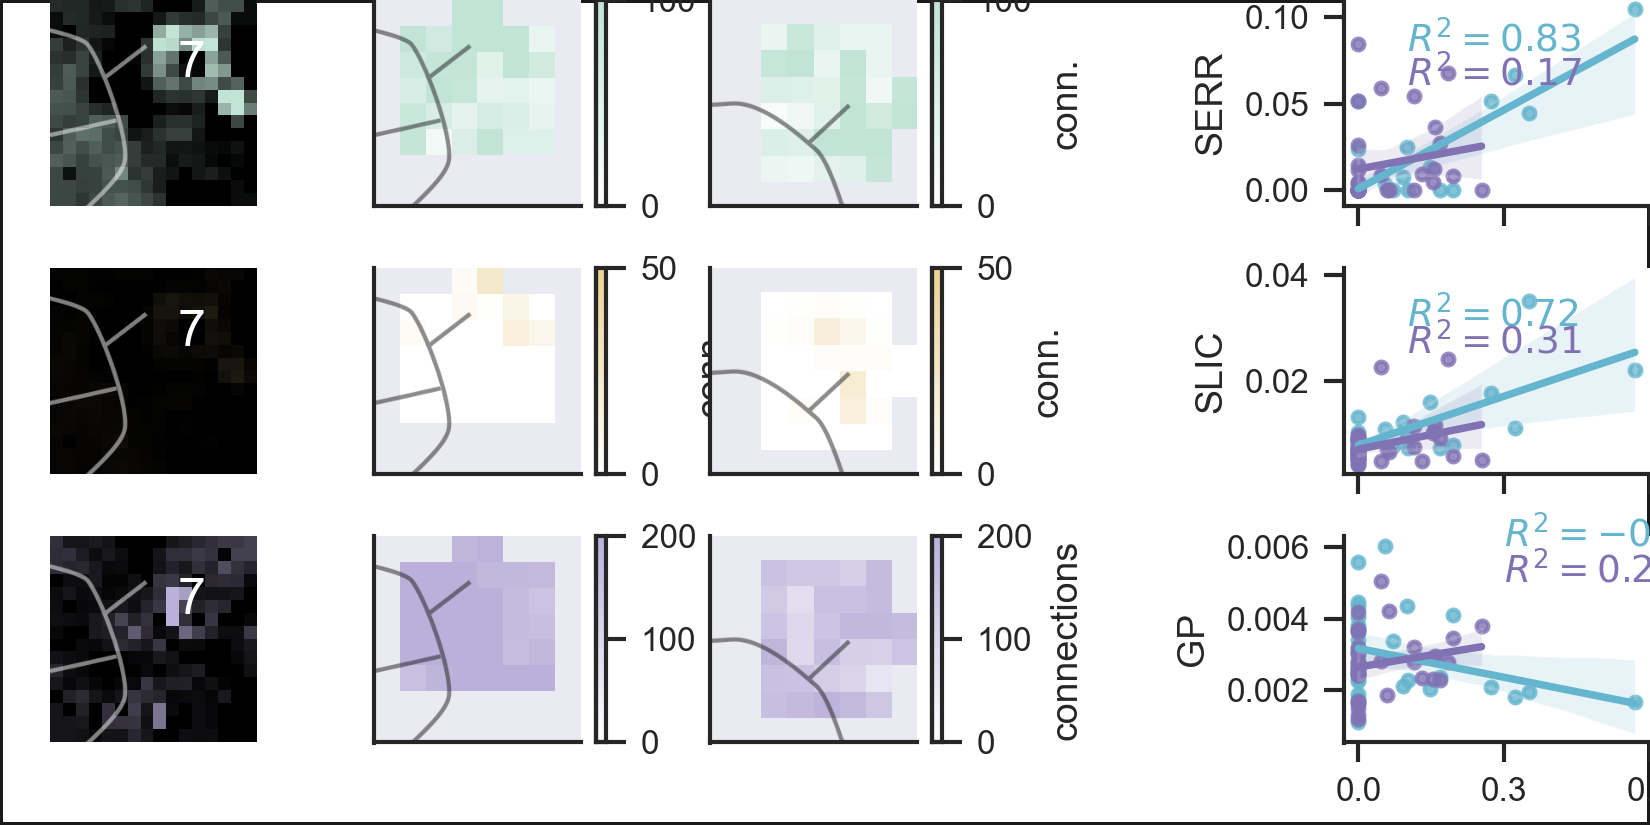

In [49]:
alpha=0.01
cutoff = 0.018
df = None
fig = plt.figure(figsize=(5.5, 2.75), dpi=300, edgecolor='k', linewidth=1)
wr = [0.2, 0.2, 0.2, 0.2, 0.2]
grid3 = GridSpec(3, 5, width_ratios=wr, wspace=0.1, hspace=0.3)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)

# Example maps
idx = -2
fig.add_subplot(grid3[0,0])
im = plot_annotated_spatial_drive_map_stim(example_maps_slic[idx], example_maps_site[idx], 
                                           example_maps_subject[idx], 'lm1', example_maps_theta[idx], 
                                           cmap=cmap_slic, clim=(0,0.1), interp=True, 
                                           colorbar=False, color='w')
plt.axis('off')
fig.add_subplot(grid3[1,0])
im = plot_annotated_spatial_drive_map_stim(example_maps_accllr[idx], example_maps_site[idx], 
                                           example_maps_subject[idx], 'lm1', example_maps_theta[idx], 
                                           cmap=cmap_accllr, clim=(0,1), interp=True, 
                                           colorbar=False, color='w')  
plt.axis('off')
fig.add_subplot(grid3[2,0])
im = plot_annotated_spatial_drive_map_stim(example_maps_gc[idx], example_maps_site[idx], 
                                           example_maps_subject[idx], 'lm1', example_maps_theta[idx], 
                                           cmap=cmap_granger, clim=(0,0.01), interp=True, 
                                           colorbar=False, color='w')  
plt.axis('off')


# Volume summary
for idx, subject, theta, data in zip([0, 1], ['beignet', 'affi'], [0, 90], [b_all_sites, a_all_sites]):
        
    print(f'{subject}:\n-----------------\n')

    # AUC
    volume, p = calc_volume(data['erp_map'], data['erp_null_maps'], alpha=alpha)
        
    # SLIC
    f = data['freqs']
    t = data['time']
    coh_map = data['slic_map']
    null_maps = data['slic_null_maps']
    p = [calc_tfr_mean_fdrc_ranktest(f, t, cm, nm, band=band, window=(0,1), alpha=alpha)[1] for cm, nm in zip(coh_map, null_maps)]
    d = [calc_tfr_mean_fdrc_ranktest(f, t, cm, nm, band=band, window=(0,1), alpha=alpha)[0] for cm, nm in zip(coh_map, null_maps)]
    counts = count_significant_connections(p, alpha=alpha)
    slic_counts = counts.copy()
    slic = [np.nanmean(dd[pp<alpha]) for pp, dd in zip(p, d)]
    
    ax = fig.add_subplot(grid3[0,idx+1])
    ax.set_facecolor('#EAEAF2')
    im, pcm = plot_annotated_stim_drive_data(np.array(counts).astype(float), subject, 'lm1', 
                                             theta, cmap=cmap_slic_inv, interpolate=False, 
                                             nan_color="#00000000", colorbar=True)
    ax.set(xticks=[], yticks=[], xlabel='', ylabel='')
    im.set_clim(0,100)
    pcm.set_ticks([0,100])
    pcm.set_label('conn.')
    sns.despine(left=True, bottom=True, ax=ax)

    stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=theta)
    grid_size = (6,6)
    ncc, _ = calc_spatial_data_correlation([volume, counts], stim_pos, interp=True, grid_size=grid_size)
    print(ncc[0,1])
    print(f"SLIC found mean: {np.mean(counts):0.2f} SD: {np.std(counts):0.2f} per site")
    
    # AccLLR
    counts = []
    for stim_idx in range(len(data['accllr_latency'])):
        serr = convert_latency_to_serr(stim_idx+1, data['accllr_latency'][stim_idx], 
                                       data['erp_map'][stim_idx], data['accllr_p'][stim_idx], 
                                       alpha=alpha, latency_cutoff=cutoff)
        total = np.count_nonzero(serr)
        counts.append(total)
    accllr_counts = counts.copy()
    accllr = [np.nanmean(dd) for dd in data['accllr_map']]

    ax = fig.add_subplot(grid3[1,idx+1])
    ax.set_facecolor('#EAEAF2')
    im, pcm = plot_annotated_stim_drive_data(np.array(counts).astype(float), subject, 'lm1', 
                                             theta, cmap=cmap_accllr_inv, interpolate=False, 
                                             nan_color="#00000000", colorbar=True)
    ax.set(xticks=[], yticks=[], xlabel='', ylabel='')
    im.set_clim(0,50)
    pcm.set_ticks([0,50])
    pcm.set_label('conn.')
    sns.despine(left=True, bottom=True, ax=ax)
    print(f"AccLLR found mean: {np.mean(counts):0.2f} SD: {np.std(counts):0.2f} per site")

    # ITPC
    counts = []
    for stim_idx in range(len(data['itpc_map'])):
        diff, itpc_p = calc_fdrc_ranktest(data['itpc_map'][stim_idx], data['itpc_null_maps'][stim_idx])
        serr = convert_latency_to_serr(idx+1, data['itpc_latency'][stim_idx], 
                                       data['itpc_map'][stim_idx], itpc_p, 
                                       alpha=alpha, latency_cutoff=cutoff)
        total = np.count_nonzero(serr)
        counts.append(total)
    itpc_counts = counts.copy()
    

    stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=theta)
    grid_size = (6,6)
    ncc, _ = calc_spatial_data_correlation([volume, counts], stim_pos, interp=True, grid_size=grid_size)
    print(ncc[0,1])
    print(f"ITPC found mean: {np.mean(counts):0.2f} SD: {np.std(counts):0.2f} per site")

    # Granger
    coh_map = data['gc_map']
    null_maps = data['gc_null_maps']
    p = [calc_tfr_mean_fdrc_ranktest(f, t, cm, nm, band=band, window=(0,1), alpha=alpha)[1] for cm, nm in zip(coh_map, null_maps)]
    d = [calc_tfr_mean_fdrc_ranktest(f, t, cm, nm, band=band, window=(0,1), alpha=alpha)[0] for cm, nm in zip(coh_map, null_maps)]
    counts = count_significant_connections(p, alpha=alpha)
    gc_counts = counts.copy()
    gc = [np.nanmean(dd[pp<alpha]) for pp, dd in zip(p, d)]

    ax = fig.add_subplot(grid3[2,idx+1])
    ax.set_facecolor('#EAEAF2')
    im, pcm = plot_annotated_stim_drive_data(np.array(counts).astype(float), 
                                             subject, 'lm1', 
                                             theta, cmap=cmap_granger_inv, interpolate=False,
                                             nan_color="#00000000", colorbar=True)

    ax.set(xticks=[], yticks=[], xlabel='', ylabel='')
    im.set_clim(0,200)
    pcm.set_ticks([0,100,200])
    pcm.set_label('connections')
    sns.despine(left=True, bottom=True, ax=ax)

    stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=theta)
    grid_size = (6,6)
    ncc, _ = calc_spatial_data_correlation([volume, counts], stim_pos, interp=True, grid_size=grid_size)
    print(ncc[0,1])
    print(f"Granger found mean: {np.mean(counts):0.2f} SD: {np.std(counts):0.2f} per site")

    
    df = pd.concat([df, pd.DataFrame({"subject": subject, "volume": list(volume), 
                                      "slic": list(slic), 
                                      "accllr": list(accllr),
                                      "gc": list(gc)})
                   ])
    
    print('\n\n')
    
df_1 = df[df["subject"] == 'beignet']
df_2 = df[df["subject"] == 'affi']

# AccLLR
colors = ['c', 'm']
fig.add_subplot(grid3[0,4])
plt.gca().set_prop_cycle(color=colors)
sns.regplot(data=df_1, x="volume", y="accllr", scatter_kws={"s": 8})
sns.regplot(data=df_2, x="volume", y="accllr", scatter_kws={"s": 8})
import scipy
_, _, r1, p1, _ = scipy.stats.linregress(x=df_1["volume"], y=df_1["accllr"])
_, _, r2, p2, _ = scipy.stats.linregress(x=df_2["volume"], y=df_2["accllr"])
plt.text(0.1, 0.08, f'$R^2 = {np.round(r1,2)}$', color=colors[0], fontsize=9)
plt.text(0.1, 0.06, f'$R^2 = {np.round(r2,2)}$', color=colors[1], fontsize=9)
sns.despine()
plt.ylabel('SERR')
plt.xticks([0,0.3,0.6], labels=[])
plt.xlabel('')

# SLIC
fig.add_subplot(grid3[1,4])
plt.gca().set_prop_cycle(color=colors)
sns.regplot(data=df_1, x="volume", y="slic", scatter_kws={"s": 8})
sns.regplot(data=df_2, x="volume", y="slic", scatter_kws={"s": 8})
import scipy
_, _, r1, p1, _ = scipy.stats.linregress(x=df_1["volume"], y=df_1["slic"])
_, _, r2, p2, _ = scipy.stats.linregress(x=df_2["volume"], y=df_2["slic"])
plt.text(0.1, 0.03, f'$R^2 = {np.round(r1,2)}$', color=colors[0], fontsize=9)
plt.text(0.1, 0.025, f'$R^2 = {np.round(r2,2)}$', color=colors[1], fontsize=9)
sns.despine()
plt.ylabel('SLIC')
plt.xticks([0,0.3,0.6], labels=[])
plt.xlabel('')

# GC
fig.add_subplot(grid3[2,4])
plt.gca().set_prop_cycle(color=colors)
sns.regplot(data=df_1, x="volume", y="gc", scatter_kws={"s": 8})
sns.regplot(data=df_2, x="volume", y="gc", scatter_kws={"s": 8})
import scipy
_, _, r1, p1, _ = scipy.stats.linregress(x=df_1["volume"], y=df_1["gc"])
_, _, r2, p2, _ = scipy.stats.linregress(x=df_2["volume"], y=df_2["gc"])
plt.text(0.3, 0.006, f'$R^2 = {np.round(r1,2)}$', color=colors[0], fontsize=9)
plt.text(0.3, 0.005, f'$R^2 = {np.round(r2,2)}$', color=colors[1], fontsize=9)
sns.despine()
plt.ylabel('GP')
plt.xticks([0,0.3,0.6])
plt.xlabel('mean stim evoked\nresponse ($\\sigma$)')

filename = f'connectivity_summary.svg'
aopy.visualization.savefig(fig_dir, filename)


## Quantify map difference

In [20]:
aopy.utils.set_memory_limit_gb(500)
elec_pos, acq_ch, elecs = aopy.data.load_chmap()

In [21]:
stim_site = 6
subject = 'beignet'
subj_data = aopy.data.pkl_read(
    f'{subject}_metric_comparison_bootstrap_{version}.pkl',
    postproc_dir)
idx = np.where(subj_data['stim_sites'] == stim_site)[0][0]
print(idx, len(subj_data['site_dists']))
observed_dists = subj_data['site_dists'][idx]
observed_corr = subj_data['site_corr_mats'][idx]

3 12


In [22]:
# Within vs across
df = None
for subject in ['affi', 'beignet']:
    subj_data = aopy.data.pkl_read(
        f'{subject}_metric_comparison_bootstrap_{version}.pkl',
        postproc_dir)
    for idx in range(len(subj_data['site_corr_mats'])):
        corr = subj_data['site_corr_mats'][idx]
        within = [np.mean([c[1,0], c[4,5]]) for c in corr]
        across = [np.mean(c[:2,4:]) for c in corr]
        stim_stim = [c[1,0]-np.mean(c[2:4,:2]) for c in corr]
        stim_rest = [c[1,0]-np.mean(c[4:6,:2]) for c in corr]

        df = pd.concat([df, pd.DataFrame({
            'subject': subject, 'within': within, 'across': across, 'site': subj_data['stim_sites'][idx]
        })])
df.reset_index(inplace=True)

In [23]:
display(df)

,index,subject,within,across,site
0,0,affi,0.549412,0.285370,5
1,1,affi,0.573258,0.216081,5
2,2,affi,0.574003,0.114761,5
3,3,affi,0.502904,0.214215,5
4,4,affi,0.698771,0.198855,5
...,...,...,...,...,...
775,25,beignet,0.498970,0.014877,29
776,26,beignet,0.642637,0.008518,29
777,27,beignet,0.605586,-0.008889,29
778,28,beignet,0.663179,0.041800,29


In [24]:
# Plot scatter of within vs across for latency vs slic
grouped = df.groupby('site').agg(
    within_mean=('within', 'mean'),
    across_mean=('across', 'mean'),
    within_err=('within', 'std'),
    across_err=('across', 'std'),
    subject=('subject', 'first')  # assuming same subject per site
).reset_index()

### Plot for figure 3

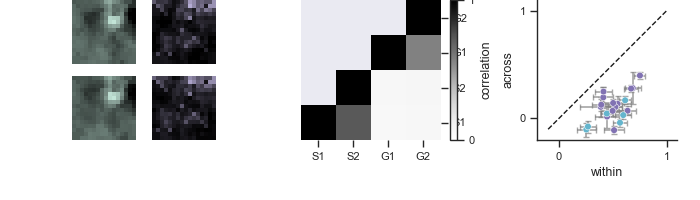

In [25]:
plt.figure(figsize=(7,2))
plt.subplots_adjust(left=0.1, right=1, top=1., bottom=0.3, wspace=0.2)

mean_slic = np.mean(observed_dists[0],axis=0)
mean_accllr = np.nanmean(observed_dists[1],axis=0)
mean_gc = np.mean(observed_dists[2],axis=0)
clim_slic = (np.min(mean_slic),np.max(mean_slic))
clim_accllr = (np.nanmin(mean_accllr),np.nanmax(mean_accllr))
clim_gc = (np.min(mean_gc),np.max(mean_gc))

for idx in range(2):
    plt.subplot(2, 8, idx*8 + 1)
    im = aopy.visualization.plot_spatial_drive_map(
        np.mean(observed_dists[0][idx], axis=0), 
        elec_data=True, cmap=cmap_slic
    )
    im.set_clim(*clim_slic)
    plt.axis('off')
    
    plt.subplot(2, 8, idx*8 + 2)
    im = aopy.visualization.plot_spatial_drive_map(
        np.mean(observed_dists[2][idx], axis=0),
        elec_data=True, cmap=cmap_granger
    )
    im.set_clim(*clim_gc)
    plt.axis('off')

# Plot correlation coefficients
plt.subplot(1,3,2)
plt.gca().set_facecolor('#EAEAF2')

mat = np.mean(observed_corr, axis=0)[[0,1,4,5],:][:,[0,1,4,5]]
mat[np.tril_indices(4, k=-1)] = np.nan

im = plt.imshow(mat, vmin=0, vmax=1,
            cmap='Grays', origin='lower')
plt.xticks(range(4), ['S1', 'S2', 'G1', 'G2'])
plt.gca().yaxis.tick_right()
plt.gca().yaxis.set_label_position("right")
plt.yticks(range(4), ['S1', 'S2', 'G1', 'G2'])
plt.gca().set_aspect('equal', adjustable='box')
pcm = plt.colorbar(im, ax=plt.gca())
pcm.set_label('correlation')
pcm.set_ticks([0,1])
sns.despine(left=True, bottom=True, ax=plt.gca())

plt.subplot(1,3,3)
# Bar plot with error bars
colors = ['c', 'm']
sns.scatterplot(data=grouped, x='within_mean', y='across_mean', hue='subject', 
                zorder=1, legend=None, palette=colors)
plt.errorbar(
    grouped['within_mean'], grouped['across_mean'],
    xerr=grouped['within_err'], yerr=grouped['across_err'],
    fmt='none', ecolor='gray', alpha=0.7, capsize=2, zorder=-1
)
xy = np.linspace(-0.1, 1., 100)
plt.plot(xy, xy, 'k--', lw=1)
ax = plt.gca()
ax.set_xlim(-0.2, 1.1)
ax.set_ylim(-0.2, 1.1)
ax.set_aspect('equal')  
plt.xlabel('within')
plt.ylabel('across')
plt.xticks([0,1])
plt.yticks([0,1])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

filename = f'map_difference_supplement.svg'
aopy.visualization.savefig(fig_dir, filename)


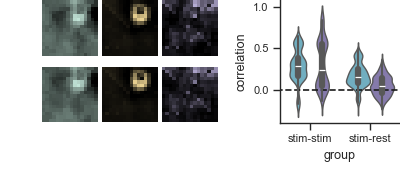

In [26]:
# Supplemental figure
plt.figure(figsize=(4,1.75))
for idx in range(2):
    plt.subplot(2, 6, idx*6 + 1)
    im = aopy.visualization.plot_spatial_drive_map(
        np.mean(observed_dists[0][idx], axis=0), 
        elec_data=True, cmap=cmap_slic
    )
    im.set_clim(*clim_slic)
    plt.axis('off')

    plt.subplot(2, 6, idx*6 + 2)
    im = aopy.visualization.plot_spatial_drive_map(
        np.mean(observed_dists[1][idx], axis=0),
        elec_data=True, cmap=cmap_accllr
    )
    im.set_clim(*clim_accllr)
    plt.axis('off')    
    
    plt.subplot(2, 6, idx*6 + 3)
    im = aopy.visualization.plot_spatial_drive_map(
        np.mean(observed_dists[2][idx], axis=0),
        elec_data=True, cmap=cmap_granger
    )
    im.set_clim(*clim_gc)
    plt.axis('off')

# Plot correlation coefficients
df = None
for subject in ['affi', 'beignet']:
    subj_data = aopy.data.pkl_read(
        f'{subject}_metric_comparison_bootstrap_{version}.pkl',
        postproc_dir)
    for idx in range(len(subj_data['site_corr_mats'])):
        corr = subj_data['site_corr_mats'][idx]
        stim_stim = [np.mean(c[2:4,:2]) for c in corr]
        stim_rest = [np.mean(c[4:6,:2]) for c in corr]

        for group, data in zip(['stim-stim', 'stim-rest'], [stim_stim, stim_rest]):
            df = pd.concat([df, pd.DataFrame({
                'subject': subject, 'within': within, 'across': across, 'group': group, 'correlation': data, 'site': subj_data['stim_sites'][idx]
            })])
df.reset_index(inplace=True)

plt.subplot(1,3,3)
plt.hlines(0, -1, 3, colors='k', linestyles='--')
ax = sns.violinplot(data=df, x='group', y='correlation', hue=df['subject'], palette=colors)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()

plt.subplots_adjust(left=0.1, right=1, top=1., bottom=0.3, wspace=0.)

filename = f'map_difference.svg'
aopy.visualization.savefig(fig_dir, filename)


## Band specificity

In [27]:
rest_df = load_df(postproc_dir, 'beignet', 'rest', version)
null_sites = [5, 16]
stim_site = 7
bands = [(0.5, 4), (4, 8), (8,12),(12,25),(25,50),(50,100),(100,200)]

In [28]:
def get_band_mask(from_band, to_band, sz, n_bands):
    m = sz * n_bands
    days = np.repeat(np.arange(n_bands), sz)  # shape (m,)
    day_i = days[:, None]  # shape (m, 1) — source
    day_j = days[None, :]  # shape (1, m) — target
    
    lower_triangle_mask = np.tril(np.ones((m, m), dtype=bool), k=-1)
    day_day_1 = (day_i == from_band) & (day_j == to_band)
    day_day_2 = (day_j == from_band) & (day_i == to_band)
    return lower_triangle_mask & (day_day_1 | day_day_2)

In [29]:
def calc_bootstrap_stats_per_band(dists_all, elec_pos, freqs, time, bands, window=(0,1)):
    
    cond_dists = []
    for band in bands:
        cond_dist = []
        for i in range(len(dists_all)):
            cond_splits_all = dists_all[i]
            cond_splits = []
            for j in range(len(cond_splits_all)):
                cond_splits.append(
                    calc_tfr_mean(
                        freqs, time, cond_splits_all[j], band=band, window=window
                    )
                )
            cond_dist.append(cond_splits)
        cond_dists.append(cond_dist)
        
    # Compare spatial correlation
    corr_mats = []
    for i in range(len(dists_all)):
        for j in range(len(dists_all[0])):
            dists = np.array([cd[i][j] for cd in cond_dists])
            cmp = calc_spatial_data_correlation(dists, 
                                                elec_pos, interp=False)[0]
            corr_mats.append(cmp)

    # d-prime pooled across bootstraps
    dprime = aopy.analysis.tuning.calc_dprime(*[np.concatenate(cd) for cd in cond_dists])

    return cond_dists, corr_mats, dprime

/home/aolab/leo/analyze/aopy/analysis/base.py:2053: UserWarning: Removing 16 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


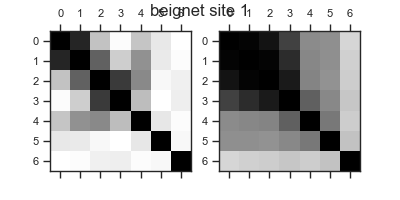

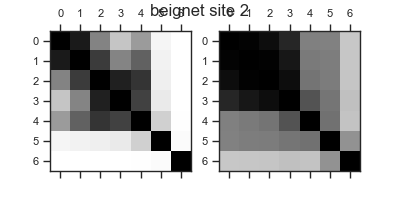

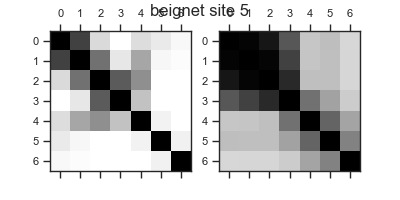

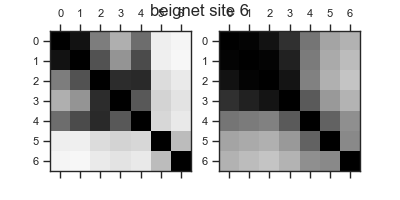

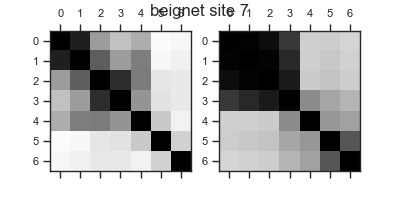

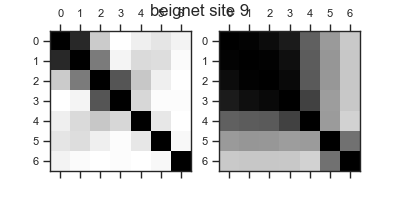

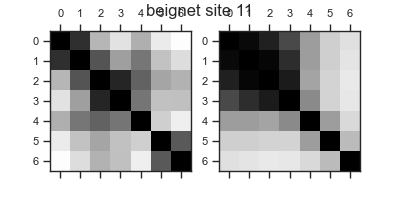

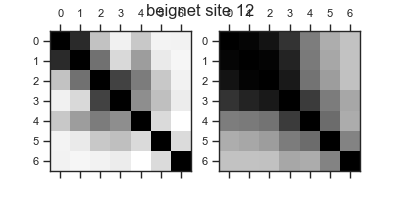

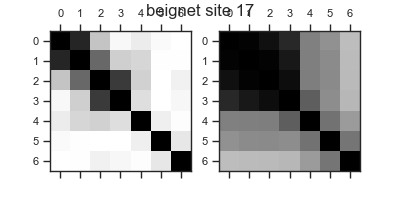

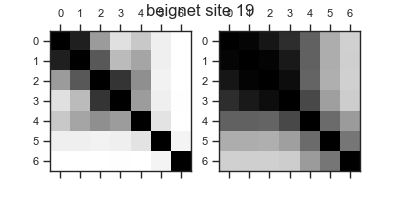

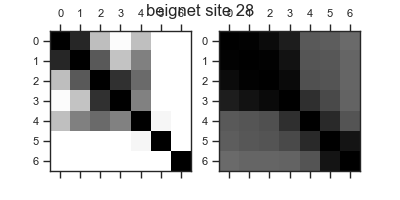

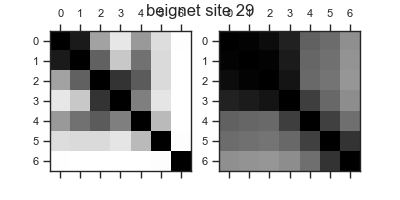

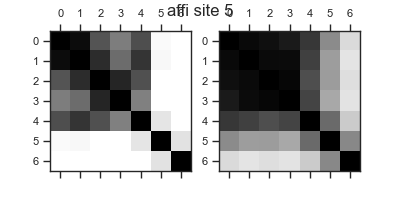

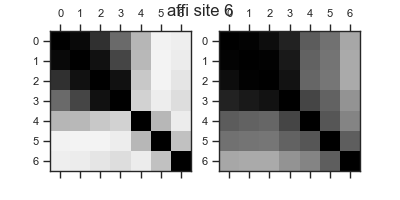

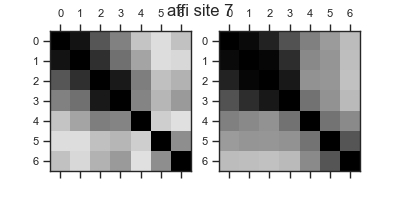

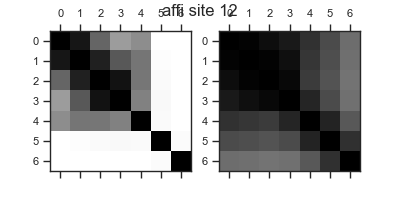

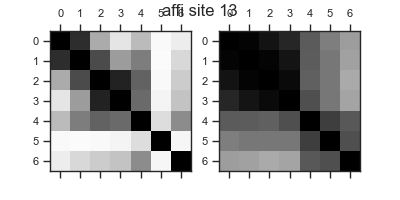

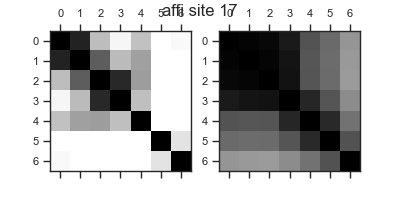

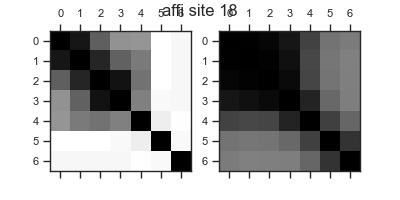

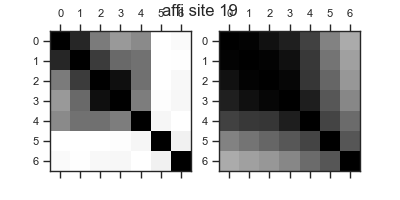

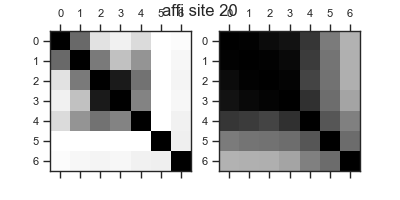

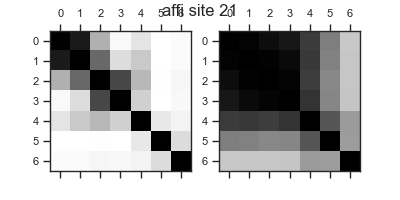

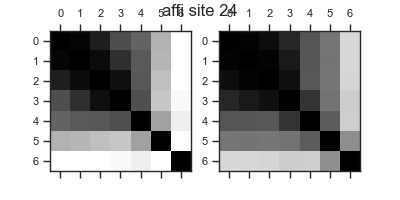

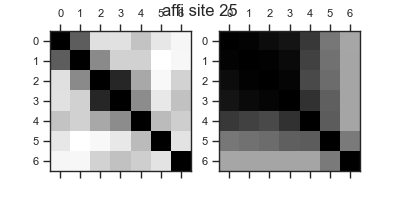

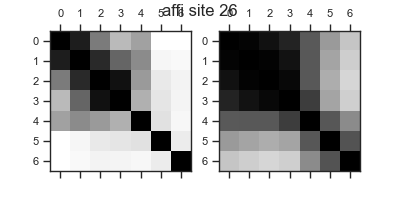

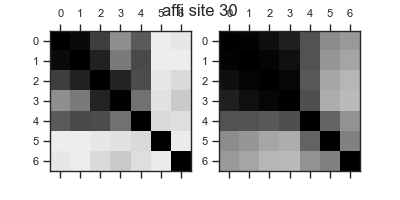

In [30]:
# Compute within/across for all sites
elec_pos, acq_ch, _ = aopy.data.load_chmap(theta=0)

subj_avg = []
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(f'{subject}_band_comparison_bootstrap_{version}.pkl',
                                   postproc_dir)

    stim_sites = subj_data['stim_sites']
    avg_slic = []
    avg_gc = []
    avg_gc_stim = []
    for idx, stim_site in enumerate(stim_sites):
        slic_dists = subj_data['slic_dists'][idx]
        gc_dists = subj_data['gc_dists'][idx]
        gc_stim_dists = subj_data['gc_stim_dists'][idx]
        
        band_dist, corr_mats, slic_dprime = calc_bootstrap_stats_per_band(
            slic_dists, elec_pos, freqs, time, bands)
        slic_dist = np.mean(corr_mats, axis=0)
        band_dist, corr_mats, gc_dprime = calc_bootstrap_stats_per_band(
            gc_dists, elec_pos, freqs, time, bands)
        gc_dist = np.mean(corr_mats, axis=0)
        band_dist, corr_mats, gc_dprime = calc_bootstrap_stats_per_band(
            gc_stim_dists, elec_pos, freqs, time, bands)
        gc_stim_dist = np.mean(corr_mats, axis=0)

        # Plot correlation coefficients
        plt.figure(figsize=(4,2))
        plt.subplot(1,2,1)
        plt.matshow(slic_dist, fignum=0, vmin=0, vmax=1, cmap='Grays')
        plt.subplot(1,2,2)
        plt.matshow(gc_dist, fignum=0, vmin=0, vmax=1, cmap='Grays')
        plt.suptitle(f"{subject} site {stim_site}")
        
        plt.show()
        
        avg_slic.append(slic_dist)
        avg_gc.append(gc_dist)
        avg_gc_stim.append(gc_stim_dist)
        
    subj_avg.append([avg_slic, avg_gc, avg_gc_stim])

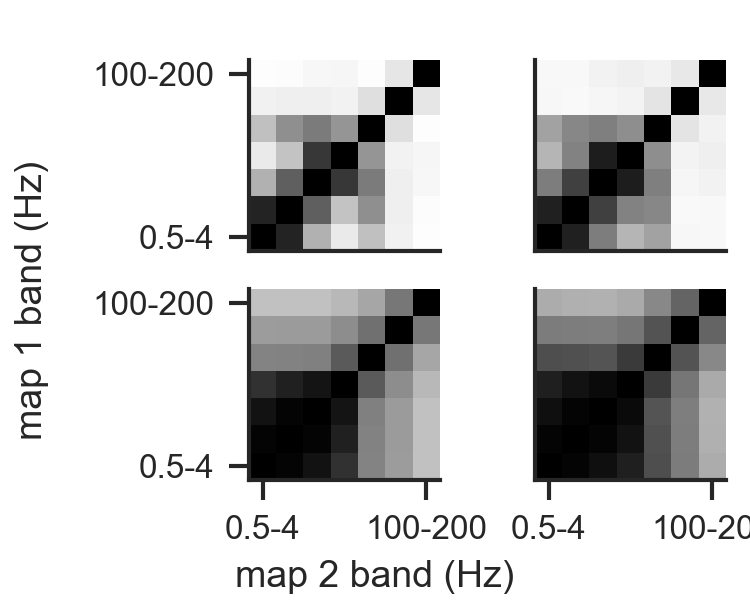

In [31]:
# Average across sites
fig = plt.figure(figsize=(2.5,2), dpi=300)
plt.subplots_adjust(left=0.3, right=1, bottom=0.2, top=0.9)
band_labels = [f"{a}-{b}" for a, b in bands]
for idx, (avg_slic, avg_gc, avg_gc_stim) in enumerate(subj_avg):

    plt.subplot(2,2,1+idx)
    avg = np.mean(avg_slic, axis=0)
    im = plt.imshow(avg, vmin=0, vmax=1, cmap='Grays', origin='lower')
    plt.xticks([])
    plt.yticks(list(range(len(avg)))[::6], labels=band_labels[::6])
    if idx == 1:
        plt.yticks([])
    sns.despine()
        
    plt.subplot(2,2,3+idx)
    avg = np.mean(avg_gc, axis=0)
    im = plt.imshow(avg, vmin=0, vmax=1, cmap='Grays', origin='lower')
    plt.xticks(list(range(len(avg)))[::6], labels=band_labels[::6])
    plt.yticks(list(range(len(avg)))[::6], labels=band_labels[::6])
    if idx == 1:
        plt.yticks([])
    sns.despine()
    
fig.supylabel('map 1 band (Hz)', fontsize=9)
fig.supxlabel("map 2 band (Hz)", fontsize=9)
filename = f'band_specificity_matrix.svg'
aopy.visualization.savefig(fig_dir, filename)


/tmp/ipykernel_1966930/2471640753.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 750x600 with 4 Axes> than <Figure size 450x600 with 2 Axes> which fig.colorbar is called on.
  pcm = plt.colorbar(im, ax=plt.gca())


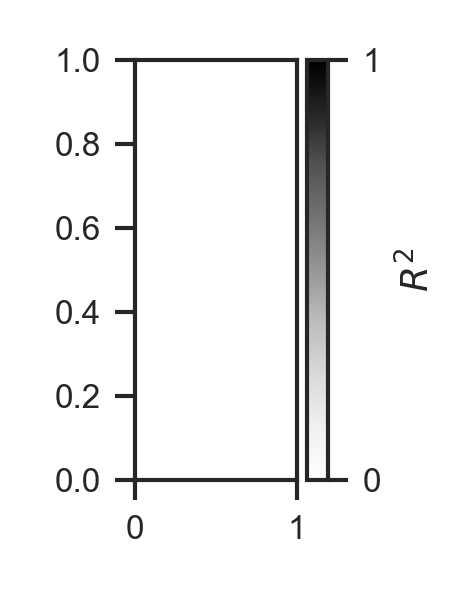

In [32]:
plt.figure(figsize=(1.5,2), dpi=300)
plt.subplots_adjust(left=0.3, right=0.75, bottom=0.2, top=0.9)
pcm = plt.colorbar(im, ax=plt.gca())
pcm.set_ticks([0, 1])
pcm.set_label('$R^2$')

filename = f'band_specificity_colorbar.svg'
aopy.visualization.savefig(fig_dir, filename)


/home/aolab/leo/analyze/aopy/analysis/base.py:2053: UserWarning: Removing 16 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


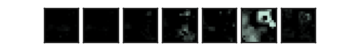

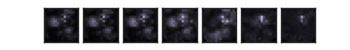

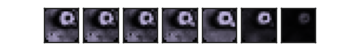

/home/aolab/leo/analyze/aopy/analysis/base.py:2053: UserWarning: Removing 16 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


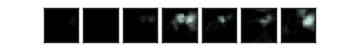

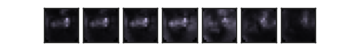

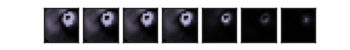

In [33]:
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(f'{subject}_band_comparison_bootstrap_{version}.pkl',
                                   postproc_dir)

    stim_sites = subj_data['stim_sites']
    avg_slic = []
    avg_gc = []
    for stim_site in [7]:
        idx = np.where(stim_sites == stim_site)[0][0]
        slic_dists = subj_data['slic_dists'][idx]
        gc_dists = subj_data['gc_dists'][idx]
        gc_stim_dists = subj_data['gc_stim_dists'][idx]

        band_dist, corr_mats, slic_dprime = calc_bootstrap_stats_per_band(
            slic_dists, elec_pos, freqs, time, bands)
        slic_dist = np.mean(band_dist, axis=(1,2))
        band_dist, corr_mats, gc_dprime = calc_bootstrap_stats_per_band(
            gc_dists, elec_pos, freqs, time, bands)
        gc_dist = np.mean(band_dist, axis=(1,2))
        band_dist, corr_mats, gc_dprime = calc_bootstrap_stats_per_band(
            gc_stim_dists, elec_pos, freqs, time, bands)
        gc_stim_dist = np.mean(band_dist, axis=(1,2))

        plot_spatial_drive_maps(slic_dist, (1,len(bands)), (0.5,0.5), cmap=cmap_slic, clim=(0,0.1), elec_data=True, 
                                interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                                nan_color='black', label_mode=None)
        filename = f'band_specificity_example_slic.svg'
        aopy.visualization.savefig(fig_dir, filename)

        plot_spatial_drive_maps(gc_dist, (1,len(bands)), (0.5,0.5), cmap=cmap_granger, clim=(0,0.03), elec_data=True, 
                                interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                                nan_color='black', label_mode=None)

        filename = f'band_specificity_example_gc.svg'
        aopy.visualization.savefig(fig_dir, filename)
        
        plot_spatial_drive_maps(gc_stim_dist, (1,len(bands)), (0.5,0.5), cmap=cmap_granger, clim=(0,0.3), elec_data=True, 
                                interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                                nan_color='black', label_mode=None)
        filename = f'band_specificity_example_supplement.svg'
        aopy.visualization.savefig(fig_dir, filename)

        plt.show()

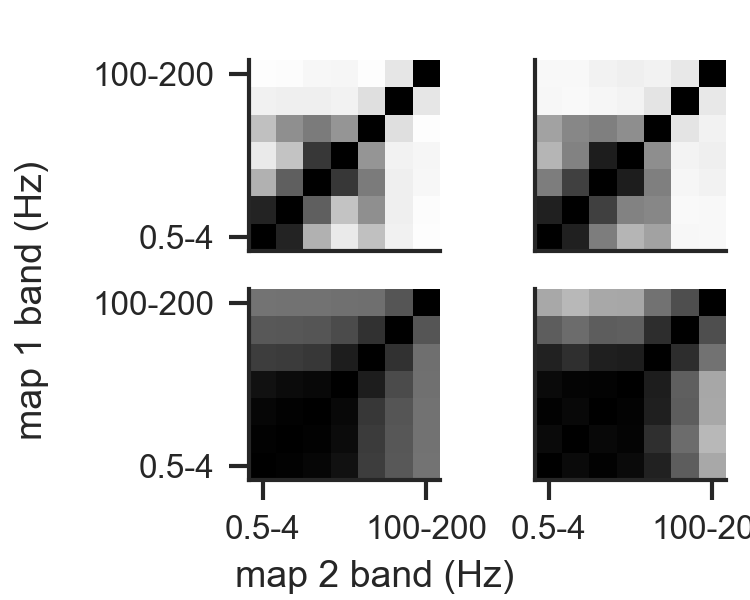

In [34]:
# Average across sites
fig = plt.figure(figsize=(2.5,2), dpi=300)
plt.subplots_adjust(left=0.3, right=1, bottom=0.2, top=0.9)
band_labels = [f"{a}-{b}" for a, b in bands]
for idx, (avg_slic, avg_gc, avg_gc_stim) in enumerate(subj_avg):

    plt.subplot(2,2,1+idx)
    avg = np.mean(avg_slic, axis=0)
    im = plt.imshow(avg, vmin=0, vmax=1, cmap='Grays', origin='lower')
    plt.xticks([])
    plt.yticks(list(range(len(avg)))[::6], labels=band_labels[::6])
    if idx == 1:
        plt.yticks([])
    sns.despine()
        
    plt.subplot(2,2,3+idx)
    avg = np.mean(avg_gc_stim, axis=0)
    im = plt.imshow(avg, vmin=0, vmax=1, cmap='Grays', origin='lower')
    plt.xticks(list(range(len(avg)))[::6], labels=band_labels[::6])
    plt.yticks(list(range(len(avg)))[::6], labels=band_labels[::6])
    if idx == 1:
        plt.yticks([])
    sns.despine()
    
fig.supylabel('map 1 band (Hz)', fontsize=9)
fig.supxlabel("map 2 band (Hz)", fontsize=9)
filename = f'band_specificity_matrix_supplement.svg'
aopy.visualization.savefig(fig_dir, filename)


## Distance from stimulation site

In [35]:
def calc_mean_distance(freqs, time, conn_map, null_maps, band, pos, bins=20):
    conn_band, p = calc_tfr_mean_fdrc_ranktest(freqs, time, conn_map, null_maps, band)
    conn_band[p>alpha] = np.nan
    
    elec_pos, acq_ch, _ = aopy.data.load_chmap(theta=0)
    dist, mean = calc_stat_over_dist_from_pos(conn_band, elec_pos, pos, 
                                              statistic=np.nanmean, bins=bins)
    angle, angle_mean = calc_stat_over_angle_from_pos(conn_band, elec_pos, pos, 
                                                      statistic=np.nanmean, bins=bins)

    norm_dist = mean / np.nansum(mean)
    norm_angle = angle_mean / np.nansum(angle_mean)

    return dist, norm_dist, angle, norm_angle

def calc_distance_stats(dist, dist_mean, angle, angle_mean):
    
    weights = dist_mean / np.nansum(dist_mean)
    mean_dist = np.nansum(weights * dist)
    var_dist = np.nansum(weights * (dist - mean_dist) ** 2)
    std_dist = np.sqrt(var_dist)

    S = np.nansum(angle_mean * np.sin(angle))
    C = np.nansum(angle_mean * np.cos(angle))
    R = np.sqrt(S**2 + C**2) / np.nansum(angle_mean)
    mean_angle = np.arctan2(S, C) % (2 * np.pi)
    var_angle = 1 - R
    
    return mean_dist, std_dist, mean_angle, var_angle

Mean over distance: 7.220604621511926
Variance over distance: 3.852819927011559
Circular mean over angle: 0.0024889934792485333
Circular variance over angle: 0.1287981219342077


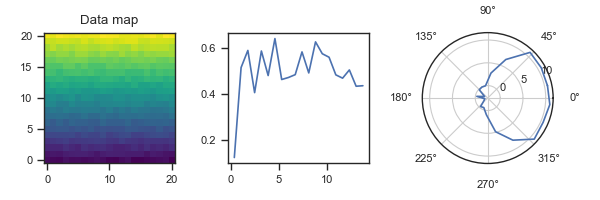

In [36]:
def test_calc_distance_stats():

    sz = [21, 21]
    elec_pos = np.array([[x, y] for x in range(sz[0]) for y in range(sz[1])])
    pos = np.array([10, 10])  # Center source

    # Data increases with distance from the center
    #data_map = np.linalg.norm(elec_pos - pos, axis=1)
    # data_map = np.ones(sz).flatten()
    # data_map[11:16] = 0
    data_map = (elec_pos[:,0] - pos[0]).astype(float)
    data_map += np.random.uniform(size=data_map.shape)
    
    # Act
    dist, mean = calc_stat_over_dist_from_pos(data_map, elec_pos, pos, statistic=np.nanmean)
    angle, angle_max = calc_stat_over_angle_from_pos(data_map, elec_pos, pos, statistic=np.nanmax)

    mean_dist, var_dist, mean_angle, var_angle = calc_distance_stats(dist, mean, angle, angle_max)

    print("Mean over distance:", mean_dist)
    print("Variance over distance:", var_dist)
    print("Circular mean over angle:", mean_angle)
    print("Circular variance over angle:", var_angle)

    plt.figure(figsize=(6,2))
    plt.subplot(1,3,1)
    plt.title("Data map")
    plt.imshow(data_map.reshape(*sz), cmap='viridis', origin='lower')

    plt.subplot(1,3,2)
    plt.plot(dist, mean)
    
    plt.subplot(1,3,3, projection='polar')
    aopy.visualization.plot_direction_tuning(angle_max, angle, ylabel='')
    
    plt.tight_layout()
test_calc_distance_stats()

### Quantify distance of connections vs frequency

In [37]:
subject = 'beignet'
stimulation_site = 7
# bands = [(0.5, 4), (4, 8), (8,12),(12,25),(25,50),(50,100),(100,200)]
bands = [(0.5, 12),(12,50),(50,200)]
theta = 0
alpha = 0.01

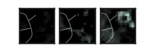

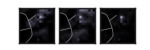

In [38]:
all_sites = aopy.data.pkl_read(
    f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)

freqs = all_sites['freqs']
time = all_sites['time']
slic_map = all_sites['slic_map'][stimulation_site-1]
slic_null_maps = all_sites['slic_null_maps'][stimulation_site-1]
gc_map = all_sites['gc_map'][stimulation_site-1]
gc_null_maps = all_sites['gc_null_maps'][stimulation_site-1]

slic_band = []
gc_band = []
for band in bands:
    diff, p = calc_tfr_mean_fdrc_ranktest(freqs, time, slic_map, slic_null_maps, band)
    scaled = scale_data_by_p_value(diff, p)
    slic_band.append(scaled)

    diff, p = calc_tfr_mean_fdrc_ranktest(freqs, time, gc_map, gc_null_maps, band)
    scaled = scale_data_by_p_value(diff, p)
    gc_band.append(scaled)

fig, axes, _, _ = plot_spatial_drive_maps(slic_band, (1,len(bands)), (0.5,0.5), cmap=cmap_slic, clim=(0,0.1), elec_data=True, 
                        interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                        nan_color='black', label_mode=None)
for ax in axes:
    overlay_sulci_on_spatial_map(subject, 'LM1', 'ECoG244', theta, color='w', ax=ax)
filename = f'band_specificity_example_slic.svg'
aopy.visualization.savefig(fig_dir, filename)

fig, axes, _, _ = plot_spatial_drive_maps(gc_band, (1,len(bands)), (0.5,0.5), cmap=cmap_granger, clim=(0,0.03), elec_data=True, 
                        interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                        nan_color='black', label_mode=None)
for ax in axes:
    overlay_sulci_on_spatial_map(subject, 'LM1', 'ECoG244', theta, color='w', ax=ax)
filename = f'band_specificity_example_gc.svg'
aopy.visualization.savefig(fig_dir, filename)


/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/leo/analyze/aopy/visualization/base.py:1841: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(per_direction_data, axis=2)
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_

slic (0.5, 12) 2.2906336349349545 0.6682698449167196
gc (0.5, 12) 2.0557937139198597 0.608142916067423
slic (12, 50) 2.236343823392871 0.7643742553077635
gc (12, 50) 2.671826256484355 0.6738533374326964
slic (50, 200) 2.930335567807563 0.7556218294178335
gc (50, 200) 2.9164016334563843 0.8533575969179179


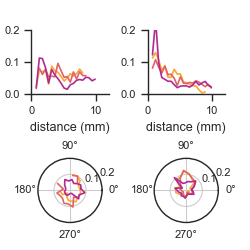

In [39]:
elec_pos, acq_ch, _ = aopy.data.load_chmap(theta=0)
stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=0)

gs = GridSpec(nrows=2, ncols=2, wspace=0.5, hspace=1)
fig = plt.figure(figsize=(2.5,2.5))

freqs = all_sites['freqs']
time = all_sites['time']
slic_map = all_sites['slic_map'][stimulation_site-1]
slic_null_maps = all_sites['slic_null_maps'][stimulation_site-1]
gc_map = all_sites['gc_map'][stimulation_site-1]
gc_null_maps = all_sites['gc_null_maps'][stimulation_site-1]

pos = stim_pos[np.where(stim_ch == stimulation_site)[0][0]]

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], projection='polar')
ax3 = fig.add_subplot(gs[0, 1])
ax4 = fig.add_subplot(gs[1, 1], projection='polar')

band_colors = list(sns.color_palette('plasma_r', n_colors=len(bands)+1))

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_prop_cycle(color=band_colors)

alpha = 0.05
for band in bands:

    # SLIC
    dist, norm_dist, angle, norm_angle = calc_mean_distance(freqs, time, slic_map, slic_null_maps, band, pos)
    dist_mean, dist_var, angle_mean, angle_var = calc_distance_stats(dist, norm_dist, angle, norm_angle)
    print('slic', band, dist_var, angle_var)
    
    ax1.plot(dist, norm_dist)
    aopy.visualization.plot_direction_tuning(norm_angle, angle, ylabel='', ax=ax2)

    # Granger
    dist, norm_dist, angle, norm_angle = calc_mean_distance(freqs, time, gc_map, gc_null_maps, band, pos)
    dist_mean, dist_var, angle_mean, angle_var = calc_distance_stats(dist, norm_dist, angle, norm_angle)
    print('gc', band, dist_var, angle_var)

    ax3.plot(dist, norm_dist)
    aopy.visualization.plot_direction_tuning(norm_angle, angle, ylabel='', ax=ax4)

ax1.set_xlabel('distance (mm)')
ax1.set_ylabel('norm.\nconnectivity')
ax1.set_xlim(0,12)
ax1.set_ylim(0,0.2)
sns.despine(ax=ax1)

ax2.set_xticks(np.linspace(0,  2*np.pi, 4, endpoint=False))
ax2.tick_params(pad=-3)
#ax2.set_rlabel_position(40)
ax2.set_ylim(0,0.2)

ax3.set_xlabel('distance (mm)')
ax3.set_xlim(0,12)
ax3.set_ylim(0,0.2)
sns.despine(ax=ax3)

ax4.set_xticks(np.linspace(0,  2*np.pi, 4, endpoint=False))
ax4.tick_params(pad=-3)
ax4.set_ylim(0,0.2)

filename = f'spatial_specificity_examples_{subject}.svg'
aopy.visualization.savefig(fig_dir, filename)


In [40]:
df = None
for subject in ['affi', 'beignet']:
    all_sites = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    volume, p = calc_volume(all_sites['erp_map'], all_sites['erp_null_maps'])
    volume[p > alpha] = np.nan

    stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=0)
    dist = []
    angle = []
    for idx, stimulation_site in enumerate(stim_ch[p < alpha]):

        b_dist = []
        b_angle = []
        for band in bands:
            freqs = all_sites['freqs']
            time = all_sites['time']
            slic_map = all_sites['slic_map'][stimulation_site-1]
            slic_null_maps = all_sites['slic_null_maps'][stimulation_site-1]
            gc_map = all_sites['gc_map'][stimulation_site-1]
            gc_null_maps = all_sites['gc_null_maps'][stimulation_site-1]

            pos = stim_pos[np.where(stim_ch == stimulation_site)[0][0]]

            dist_slic, dist_var_slic, angle_slic, angle_var_slic = calc_distance_stats(*calc_mean_distance(freqs, time, slic_map, slic_null_maps, band, pos))
            dist_gc, dist_var_gc, angle_gc, angle_var_gc = calc_distance_stats(*calc_mean_distance(freqs, time, gc_map, gc_null_maps, band, pos))

            b_dist.append([dist_var_slic, dist_var_gc])
            b_angle.append([angle_var_slic, angle_var_gc])

        dist.append(b_dist)
        angle.append(b_angle)
    
    df = pd.concat([df, pd.DataFrame({
        'subject': subject,
        'dist': dist,
        'angle': angle,
        'stim_site': stim_ch[p < alpha],
    })])
                    

/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/scipy

(15, 3, 2)
affi
dist
1.0
[1.    1.    0.972]
angle
0.004
[0.001 0.042 0.681]
(12, 3, 2)
beignet
dist
0.435
[0.339 0.81  0.19 ]
angle
0.129
[0.039 0.455 0.425]


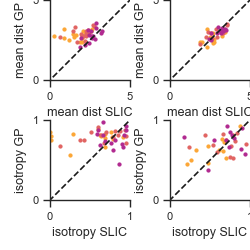

In [41]:
fig = plt.figure(figsize=(2.5,2.5))
plt.subplots_adjust(left=0.2, right=1, top=1., bottom=0.2, wspace=0.5, hspace=0.5)
band_colors = list(sns.color_palette('plasma_r', n_colors=len(bands)+1))
for subj_idx, subject in enumerate(['affi', 'beignet']):
    dist = np.array(df.loc[df['subject'] == subject, 'dist'].tolist())
    angle = np.array(df.loc[df['subject'] == subject, 'angle'].tolist())

    plt.subplot(2,2,1+subj_idx)
    plt.gca().set_prop_cycle(color=band_colors)

    print(np.shape(dist))

    for idx, band in enumerate(bands):
        plt.scatter(dist[:,idx,0], dist[:,idx,1], 5.0)
    plt.axis('equal')
    plt.xlim(0, 5)
    plt.ylim(0, 5)
    plt.xticks([0,5])
    plt.yticks([0,5])
    x = np.arange(-1, 10, 0.1)
    plt.plot(x, x, 'k--')
    plt.xlabel('mean dist SLIC')
    plt.ylabel('mean dist GP')
    sns.despine()

    plt.subplot(2,2,3+subj_idx)
    plt.gca().set_prop_cycle(color=band_colors)

    for idx, band in enumerate(bands):
        plt.scatter(angle[:,idx,0], angle[:,idx,1], 5.0)
    plt.axis('equal')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks([0,1])
    plt.yticks([0,1])

    plt.plot(x, x, 'k--')
    plt.xlabel('isotropy SLIC')
    plt.ylabel('isotropy GP')
    sns.despine()

    # Paired statistics
    print(subject)
    print('dist')
    stat, p = wilcoxon(dist[:,:,0].flatten(), dist[:,:,1].flatten(), 
                       alternative='greater', nan_policy='omit')
    print(np.round(p,3))
    stat, p = wilcoxon(dist[:,:,0], dist[:,:,1], 
                       alternative='greater', nan_policy='omit')
    print(np.round(p,3))
    
    print('angle')
    stat, p = wilcoxon(angle[:,:,0].flatten(), angle[:,:,1].flatten(), 
                       alternative='less', nan_policy='omit')
    print(np.round(p,3))
    stat, p = wilcoxon(angle[:,:,0], angle[:,:,1], 
                       alternative='less', nan_policy='omit')
    print(np.round(p,3))

filename = f'spatial_specificity_summary.svg'
aopy.visualization.savefig(fig_dir, filename)


(15, 3, 2)
(12, 3, 2)


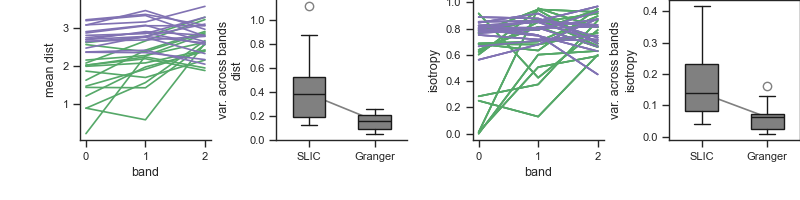

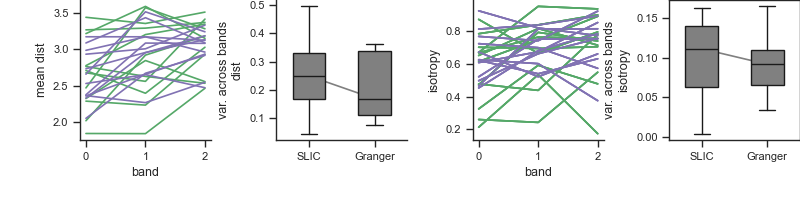

In [42]:
# Relationship between bands
for subject in ['affi', 'beignet']:
    dist = np.array(df.loc[df['subject'] == subject, 'dist'].tolist())
    angle = np.array(df.loc[df['subject'] == subject, 'angle'].tolist())

    fig = plt.figure(figsize=(8,2))
    plt.subplot(1,4,1)

    print(np.shape(dist))

    plt.plot(dist[:,:,0].T, 'g')
    plt.plot(dist[:,:,1].T, 'm')
    plt.xlabel('band')
    plt.ylabel('mean dist')
    sns.despine()

    plt.subplot(1,4,2)
    aopy.visualization.plot_boxplots([np.std(dist[:,:,0], axis=1), np.std(dist[:,:,1], axis=1)], ['SLIC', 'Granger'])
    plt.ylabel('var. across bands\ndist')

    plt.subplot(1,4,3)
    for idx, band in enumerate(bands):
        plt.plot(angle[:,:,0].T, 'g')
        plt.plot(angle[:,:,1].T, 'm')
    plt.xlabel('band')
    plt.ylabel('isotropy')
    sns.despine()

    plt.subplot(1,4,4)
    aopy.visualization.plot_boxplots([np.std(angle[:,:,0], axis=1), np.std(angle[:,:,1], axis=1)], ['SLIC', 'Granger'])
    plt.ylabel('var. across bands\nisotropy')

    plt.subplots_adjust(left=0.1, right=1, top=1., bottom=0.3, wspace=0.5)
    filename = f'spatial_specificity_summary_2_{subject}.svg'
    aopy.visualization.savefig(fig_dir, filename)


### Plots for figure 4

['c', 'm']
(15, 3, 2)
(12, 3, 2)


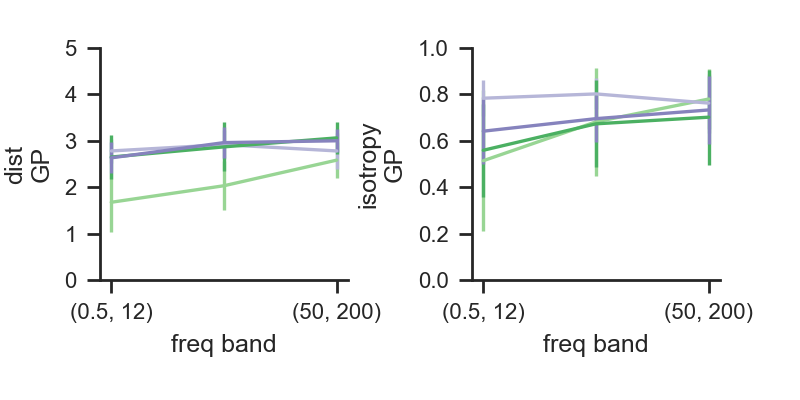

In [43]:
# Relationship between bands
fig = plt.figure(figsize=(4,2), dpi=200)
plt.subplots_adjust(bottom=0.3, wspace=0.5)

band_colors = sns.color_palette('Greens', n_colors=4)[1:3]
band_colors.extend(sns.color_palette('Purples', n_colors=4)[1:3])
print(colors)

# distance
for subj_idx, subject in enumerate(['affi', 'beignet']):
    dist = np.array(df.loc[df['subject'] == subject, 'dist'].tolist())

    plt.subplot(1,2,1)

    print(np.shape(dist))

    m = np.nanmean(dist[:,:,0], axis=0)
    std = np.nanstd(dist[:,:,0], axis=0)
    plt.errorbar(range(len(bands)), m, yerr=std, color=band_colors[subj_idx])
    plt.xlabel('freq band')
    plt.xticks([0,len(bands)-1], [bands[0], bands[-1]])
    plt.ylabel('dist\nSLIC')
    plt.ylim(0,5)
    sns.despine()

    m = np.nanmean(dist[:,:,1], axis=0)
    std = np.nanstd(dist[:,:,1], axis=0)
    plt.errorbar(range(len(bands)), m, yerr=std, color=band_colors[subj_idx+2])
    plt.xlabel('freq band')
    plt.xticks([0,len(bands)-1], [bands[0], bands[-1]])
    plt.ylabel('dist\nGP')
    plt.ylim(0,5)
    sns.despine()

# isotropy
for subj_idx, subject in enumerate(['affi', 'beignet']):
    angle = np.array(df.loc[df['subject'] == subject, 'angle'].tolist())

    plt.subplot(1,2,2)
    m = np.nanmean(angle[:,:,0], axis=0)
    std = np.nanstd(angle[:,:,0], axis=0)
    plt.errorbar(range(len(bands)), m, yerr=std, color=band_colors[subj_idx])
    plt.xlabel('freq band')
    plt.xticks([0,len(bands)-1], [bands[0], bands[-1]])
    plt.ylabel('isotropy\nSLIC')
    plt.ylim(0,1)
    sns.despine()

    m = np.nanmean(angle[:,:,1], axis=0)
    std = np.nanstd(angle[:,:,1], axis=0)
    plt.errorbar(range(len(bands)), m, yerr=std, color=band_colors[subj_idx+2])
    plt.xlabel('freq band')
    plt.xticks([0,len(bands)-1], [bands[0], bands[-1]])
    plt.ylabel('isotropy\nGP')
    plt.ylim(0,1)
    sns.despine()
    
filename = f'spatial_specificity_summary.svg'
aopy.visualization.savefig(fig_dir, filename)
